In [18]:
from IPython.core.display import HTML
display(HTML("""
<style>
/* Centrar DataFrames */
.dataframe {
    margin-left: auto !important;
    margin-right: auto !important;
}
/* Centrar Gráficos de Matplotlib/Seaborn */
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
"""))

**EDA Fase 1: Diagnóstico de RECH0 (Características del Hogar / Geografía)**

Objetivo: Descubrir empíricamente qué variables y etiquetas contiene realmente este módulo en la ventana histórica 2007-2024. 

No haremos suposiciones de filtrado ni unificación hasta que agrupemos lógicamente las variables e imprimamos su distribución.

In [19]:
import pandas as pd
import gc
from mnp.ingestion.loader import load_endes
from IPython.display import display


# 1. Carga de historial desde 2007 para RECH0
history = load_endes(year=range(2007, 2025), module='household', record='household_characteristics', meta=True)

frames = []
diccionario = {} # labels del ultimo año
historial_etiquetas = {} # labels de columna por año
historial_valores = {} # labels de valores por año

# Extraemos y liberamos memoria progresivamente usando pop()
for yr in sorted(list(history.keys())):
    df_yr, meta_yr = history.pop(yr)
    frames.append(df_yr.assign(year=yr))
    diccionario.update(meta_yr.column_names_to_labels)
    historial_etiquetas[yr] = meta_yr.column_names_to_labels
    historial_valores[yr] = meta_yr.variable_value_labels

df_rech0 = pd.concat(frames, ignore_index=True)
del frames
gc.collect() # Forzar limpieza de memoria

print(f"Registros RECH0 totales: {len(df_rech0)}")
print(f"Columnas RECH0 totales: {df_rech0.shape[1]}")

2026-06-01 19:02:06.059 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH0.SAV desde Modulo64 [Alias: household_characteristics]
2026-06-01 19:02:06.558 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH0.sav desde Modulo64 [Alias: household_characteristics]
2026-06-01 19:02:07.166 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH0.SAV desde Modulo64 [Alias: household_characteristics]
2026-06-01 19:02:07.610 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH0.SAV desde Modulo64 [Alias: household_characteristics]
2026-06-01 19:02:08.066 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH0.sav desde Modulo64 [Alias: household_characteristics]
2026-06-01 19:02:08.511 | INFO     | mnp.ingestion.loader:load_endes:375 - ✓ Cargando registro: RECH0.sav desde Modulo64 [Alias: household_characteristics]
2026-06-01 19:02:09.064 | INFO     | mnp.ingestion.loader:load_e

## Revisión de Labels (Schema Drift)

In [20]:
# 1. Analizador Global de "Variable Label Drift" (Mutación de Nombres Descriptivos)
from collections import defaultdict
from mnp.ingestion.loader import format_year_ranges

reporte_etiquetas = defaultdict(lambda: defaultdict(list))
todas_las_columnas = {c for yr_cols in historial_etiquetas.values() for c in yr_cols}

for col in sorted(todas_las_columnas):
    for yr, yr_cols in historial_etiquetas.items():
        if col in yr_cols:
            val = yr_cols[col]
            # Si es nulo, vacío, "None" textual o idéntico al nombre de la columna, lo omitimos como etiqueta válida
            if val is None or str(val).strip() == "" or str(val).strip() == "None" or str(val).strip().upper() == col.upper():
                continue
                
            descripcion = str(val).strip()
            reporte_etiquetas[col][descripcion].append(yr)

eti_mutadas = {k: v for k, v in reporte_etiquetas.items() if len(v) > 1}
eti_estables = {k: v for k, v in reporte_etiquetas.items() if len(v) == 1}

print("--- REPORTE GLOBAL DE MUTACIÓN DE DESCRIPCIONES (2007 - 2024) ---")
print(f"Total de columnas físicas históricas detectadas: {len(todas_las_columnas)}\n")

for titulo, variables in [("✅ DESCRIPCIONES ESTABLES", eti_estables), ("⚠️ DESCRIPCIONES MUTADAS", eti_mutadas)]:
    print(f"{titulo} ({len(variables)}):")
    for var, versiones in variables.items():
        print(f"\n[{var}] | Apariciones: {sum(len(y) for y in versiones.values())} años")
        for desc_str, anios in versiones.items():
            print(f"  -> Años {format_year_ranges(anios)}: {desc_str}")
    print("\n" + "="*80 + "\n")

# 2. Auditoría de Descripciones Faltantes
print("--- AUDITORÍA DE DESCRIPCIONES FALTANTES ---")
print("Buscando en qué años las columnas existieron, pero el INEI olvidó ponerles un texto descriptivo (o repitieron el nombre de la variable).\n")
alertas_desc = 0
for col in sorted(todas_las_columnas):
    anios_existe = []
    anios_sin_desc = []
    for yr, yr_cols in historial_etiquetas.items():
        if col in yr_cols:
            anios_existe.append(yr)
            val = yr_cols[col]
            # Mismo criterio de vacío absoluto
            if val is None or str(val).strip() == "" or str(val).strip() == "None" or str(val).strip().upper() == col.upper():
                anios_sin_desc.append(yr)
                
    if anios_sin_desc:
        alertas_desc += 1
        print(f"⚠️ {col} | Existe físicamente en {format_year_ranges(anios_existe)} | PERO SIN DESCRIPCIÓN en: {format_year_ranges(anios_sin_desc)}")

if alertas_desc == 0:
    print("✅ ¡Increíble! Todas las variables tienen un texto descriptivo válido en todos los años.")
else:
    print(f"\nTotal alertas de descripciones faltantes: {alertas_desc}")


--- REPORTE GLOBAL DE MUTACIÓN DE DESCRIPCIONES (2007 - 2024) ---
Total de columnas físicas históricas detectadas: 61

✅ DESCRIPCIONES ESTABLES (15):

[HV005A] | Apariciones: 1 años
  -> Años 2008: Sample weight Departamental

[HV005X] | Apariciones: 1 años
  -> Años 2015: Factor de ponderación niño menor de 5 años 2015

[ID1] | Apariciones: 13 años
  -> Años 2010-2016, 2019-2024: Año

[LATITUDY] | Apariciones: 1 años
  -> Años 2022: Latitud del conglomerado

[LONGITUDX] | Apariciones: 1 años
  -> Años 2022: Longitud del conglomerado

[NCONGLOME] | Apariciones: 5 años
  -> Años 2019-2023: Número de Conglomerado (proveniente del marco)

[NCONGLOME1] | Apariciones: 1 años
  -> Años 2024: Número de Conglomerado (proveniente del marco)

[UBIGEO] | Apariciones: 6 años
  -> Años 2019-2024: Código de Ubicación Gegráfica

[codccpp] | Apariciones: 2 años
  -> Años 2016-2017: Codigo de centro poblado

[hv005] | Apariciones: 1 años
  -> Años 2016: Factor de ponderacion

[hv022] | Apariciones: 1 a

In [21]:
from collections import defaultdict
from mnp.ingestion.loader import format_year_ranges

# 1. Analizar "Value Label Drift"
reporte_vars = defaultdict(lambda: defaultdict(list))
todas_vars = {v for yr_dict in historial_valores.values() for v in yr_dict}

for var in sorted(todas_vars):
    for yr, yr_dict in historial_valores.items():
        if var in yr_dict:
            clean_map = str({int(float(k)) if isinstance(k, (int, float)) else k: str(v).strip() for k, v in yr_dict[var].items()})
            reporte_vars[var][clean_map].append(yr)

mutadas = {k: v for k, v in reporte_vars.items() if len(v) > 1}
estables = {k: v for k, v in reporte_vars.items() if len(v) == 1}

print("--- REPORTE GLOBAL DE VALUE LABEL DRIFT (2007 - 2024) ---")
print(f"Total variables categóricas detectadas: {len(todas_vars)}\n")

for titulo, variables in [("ESTABLES", estables), ("⚠️ MUTADAS", mutadas)]:
    print(f"{titulo} ({len(variables)}):")
    for var, versiones in variables.items():
        print(f"\n[{var}] {diccionario.get(var, '')} | Apariciones: {sum(len(y) for y in versiones.values())} años")
        for map_str, anios in versiones.items():
            print(f"  -> Años {format_year_ranges(anios)}: {map_str}")
    print("\n" + "="*80 + "\n")

# 2. Auditoría de Diccionarios Faltantes
print("--- AUDITORÍA DE DICCIONARIOS FALTANTES ---")
vars_upper = {v.upper() for v in todas_vars}
alertas = 0

for var_u in sorted(vars_upper):
    anios_existe, anios_sin_dict, nombres = [], [], set()
    for yr, cols in historial_etiquetas.items():
        real_name = next((c for c in cols if c.upper() == var_u), None)
        if real_name:
            anios_existe.append(yr)
            nombres.add(real_name)
            if real_name not in historial_valores[yr]:
                anios_sin_dict.append(yr)
                
    if anios_sin_dict:
        alertas += 1
        print(f"⚠️ {var_u} ({', '.join(nombres)}) | Existe: {format_year_ranges(anios_existe)} | SIN DICCIONARIO: {format_year_ranges(anios_sin_dict)}")

print(f"\nTotal alertas de diccionarios faltantes: {alertas}")


--- REPORTE GLOBAL DE VALUE LABEL DRIFT (2007 - 2024) ---
Total variables categóricas detectadas: 11

ESTABLES (3):

[HV023] Dominio | Apariciones: 18 años
  -> Años 2007-2024: {1: 'Amazonas', 2: 'Ancash', 3: 'Apurimac', 4: 'Arequipa', 5: 'Ayacucho', 6: 'Cajamarca', 7: 'Callao', 8: 'Cusco', 9: 'Huancavelica', 10: 'Huanuco', 11: 'Ica', 12: 'Junin', 13: 'La Libertad', 14: 'Lambayeque', 15: 'Lima', 16: 'Loreto', 17: 'Madre de Dios', 18: 'Moquegua', 19: 'Pasco', 20: 'Piura', 21: 'Puno', 22: 'San Martin', 23: 'Tacna', 24: 'Tumbes', 25: 'Ucayali'}

[HV024] Región | Apariciones: 18 años
  -> Años 2007-2024: {1: 'Amazonas', 2: 'Ancash', 3: 'Apurimac', 4: 'Arequipa', 5: 'Ayacucho', 6: 'Cajamarca', 7: 'Callao', 8: 'Cusco', 9: 'Huancavelica', 10: 'Huanuco', 11: 'Ica', 12: 'Junin', 13: 'La Libertad', 14: 'Lambayeque', 15: 'Lima', 16: 'Loreto', 17: 'Madre de Dios', 18: 'Moquegua', 19: 'Pasco', 20: 'Piura', 21: 'Puno', 22: 'San Martin', 23: 'Tacna', 24: 'Tumbes', 25: 'Ucayali'}

[hv022] Estrato | Ap

## Revisión de Nulos (Evolución Histórica por Año)

In [22]:
# 2. Descubrimiento: Porcentaje de nulos de la data real
nulos = df_rech0.isna().mean().sort_values(ascending=False) * 100
df_nulos_global = nulos.to_frame(name='% Nulos').round(1)

df_nulos_global.insert(
    0, 
    'Etiqueta',
    df_nulos_global.index.map(
        lambda x: diccionario.get(x, 'Sin etiqueta')
    )
)

display(df_nulos_global[df_nulos_global['% Nulos'] > 0])
display(df_nulos_global[df_nulos_global['% Nulos'] == 0])

,Etiqueta,% Nulos
HV028,Peso de muestra masculino,100.0
HV031,Editor de campo,100.0
lat_ccpp,Latitud,94.0
long_ccpp,Longitud,94.0
hv022,Estrato,94.0
HV005X,Factor de ponderación niño menor de 5 años 2015,94.0
HV005A,Sample weight Departamental,94.0
NCONGLOME1,Número de Conglomerado (proveniente del marco),93.9
ubigeo,ubigeo,93.8
nconglome,Número de Conglomerado (proveniente del marco),93.8


,Etiqueta,% Nulos
HV032,Editor de la oficina,0.0
HV027,Selección para hombre/esposo,0.0
HV021,Unidad de muestreo primario (conglomerado),0.0
HV025,Área de residencia,0.0
HV023,Dominio,0.0
HV024,Región,0.0
HV013,Número de miembros de facto (personas que durmieron la noche anterior),0.0
HV015,Resultado de la entrevista en el hogar,0.0
HV002,Vivienda,0.0
HV008,Fecha de entrevista meses (CMC),0.0


**Clasificación Inicial por Categorías**

In [23]:
# 1. Reorganizamos nuestras categorías con todas las variables agrupadas
categorias = {
    'geografia': [
        #
        'LATITUDY', 'latitudy', 'lat_ccpp',
        'LONGITUDX', 'longitudx', 'long_ccpp',
        'UBIGEO', 'ubigeo', 
        'NOMCCPP', 'nomccpp',
        'codccpp', 'CODCCPP', 
        #
        'HV025','HV024','HV026','HV040'
    ],
    'muestreo': [
        #
        'NCONGLOME1', 'nconglome', 'NCONGLOME',
        'HV005X', 'HV005A', 'hv005', 'HV005',
        'hv022', 'HV022',
        #
        'HV001','HV004','HV020','HV021','HV023','HV027','HV028','HV033','HV042','HV043','HV044'
    ],
    'administrativa': [
        #
        'year','ID1',
        'HV002', 'HV002A', 
        #
        'HHID','HV000','HV003','HV008','HV019','HV016','HV006','HV018','HV007','HV015','HV017','HV030','HV031','HV032'
    ],
    'demografia': [
        'HV009','HV010','HV011','HV012','HV013','HV014','HV035','HV041'
    ]
}

In [24]:
pd.set_option('display.max_colwidth', None)
print("--- TIPOS DE DATOS POR CATEGORÍA ---")
for cat, lista in categorias.items():
    print(f"\nCategoría: {cat.upper()}")
    
    # Recorremos la 'lista' si se encuentra en rech0
    vars_validas = [vars for vars in lista if vars in df_rech0.columns]
    
    # Extraemos los dtypes de rech0
    df_dtypes = df_rech0[vars_validas].dtypes.to_frame(name='Dtype')
    df_dtypes.insert(1, 'Etiqueta', df_dtypes.index.map(lambda label: diccionario.get(label, 'Sin etiqueta')))
    
    display(df_dtypes)


--- TIPOS DE DATOS POR CATEGORÍA ---

Categoría: GEOGRAFIA


,Dtype,Etiqueta
LATITUDY,float64,NaN
latitudy,float64,Latitud del conglomerado
lat_ccpp,float64,Latitud
LONGITUDX,float64,NaN
longitudx,float64,Longitud del conglomerado
long_ccpp,float64,Longitud
UBIGEO,str,Código de Ubicación Gegráfica
ubigeo,str,ubigeo
NOMCCPP,str,Nombre del Centro Poblado
nomccpp,str,Nombre de centro poblado



Categoría: MUESTREO


,Dtype,Etiqueta
NCONGLOME1,str,Número de Conglomerado (proveniente del marco)
nconglome,float64,Número de Conglomerado (proveniente del marco)
NCONGLOME,object,Número de Conglomerado (proveniente del marco)
HV005X,float64,Factor de ponderación niño menor de 5 años 2015
HV005A,float64,Sample weight Departamental
hv005,float64,Factor de ponderacion
HV005,float64,Factor de ponderación
hv022,float64,Estrato
HV022,float64,Estrato
HV001,float64,Conglomerado



Categoría: ADMINISTRATIVA


,Dtype,Etiqueta
year,int64,Sin etiqueta
ID1,float64,Año
HV002,float64,Vivienda
HV002A,float64,Hogar
HHID,str,Identificacion Cuestionario del Hogar
HV000,str,Código del país
HV003,float64,Número de orden del Informante del cuestionario del hogar
HV008,float64,Fecha de entrevista meses (CMC)
HV019,float64,Keyer identification
HV016,float64,Day of interview



Categoría: DEMOGRAFIA


,Dtype,Etiqueta
HV009,float64,Total de personas en el hogar
HV010,float64,Número de mujeres elegibles para entrevista individual
HV011,float64,Número de hombres elegibles por hogar
HV012,float64,Número de miembros de jure (residentes habituales)
HV013,float64,Número de miembros de facto (personas que durmieron la noche anterior)
HV014,float64,Número de niños menores de 5 años
HV035,float64,Número de niños elegibles para altura y peso
HV041,float64,Número de mujeres con medición de peso y talla


In [25]:
import textwrap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def analizar_categoria(nombre_categoria, cmap, figsize=(14, 8)):
    # 1. Filtramos las variables que pertenecen a la categoría y existen en el df
    vars_cat = categorias[nombre_categoria]
    vars_cat = [v for v in vars_cat if v in df_rech0.columns]
    
    # 2. Calculamos el % de nulos por año
    df_nulos = df_rech0.groupby('year')[vars_cat].apply(lambda df: df.isna().mean() * 100)
    
    # 3. Preparamos la Matriz para imprimir (insertando la etiqueta al inicio)
    matriz_imprimir = df_nulos.T.copy()
    matriz_imprimir.insert(0, 'Etiqueta', matriz_imprimir.index.map(lambda x: diccionario.get(x, 'Sin etiqueta')))
    
    # Mostramos la tabla sin límite de texto
    pd.set_option('display.max_colwidth', None)
    print(f"\n{'='*60}")
    print(f"ANÁLISIS DE CATEGORÍA: {nombre_categoria.upper()}")
    print(f"{'='*60}")
    display(matriz_imprimir)
    
    # 4. Dibujamos el Heatmap
    plt.figure(figsize=figsize)
    sns.heatmap(df_nulos.T, annot=True, fmt=".0f", cmap=cmap, vmin=0, vmax=100, cbar_kws={'label': '% de Nulos'})
    plt.title(f"Evolución: {nombre_categoria.capitalize()} (% de Nulos por Año)", pad=20, fontsize=14)
    plt.xlabel("Año", fontsize=12)
    plt.ylabel(f"Variables de {nombre_categoria.capitalize()}", fontsize=12)
    plt.tight_layout()
    plt.show()

### Categoría geografía
Resultados de la celda anterior la celda anterior agrupados
| Variable | Label | Nulos |
|--|--|--|
| HV024 | Región | 0.0% nulos |
| HV025 | Área de residencia | 0.0% nulos |
| HV026 | Lugar de residencia | 0.6% nulos |
| HV040 | Altitud del conglomerado en metros | 0.0% nulos |
| long_ccpp | Longitud | 94.0% nulos |
| LONGITUDX | Longitud | 81.6% nulos |
| longitudx | Longitud del conglomerado | 39.8% nulos |
| lat_ccpp | Latitud | 94.0% nulos |
| LATITUDY | Latitud | 81.6% nulos |
| latitudy | Latitud del conglomerado | 39.8% nulos |
| NOMCCPP | Nombre del Centro Poblado | 56.9% nulos |
| nomccpp | Nombre de centro poblado | 88.0% nulos |
| CODCCPP | Codigo de Centro Poblado | 56.9% nulos |
| codccpp | Codigo de centro poblado | 88.0% nulos |
| UBIGEO | Código de Ubicación Geográfica | 63.0% nulos |
| ubigeo | ubigeo | 93.8% nulos |


ANÁLISIS DE CATEGORÍA: GEOGRAFIA


year,Etiqueta,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
LATITUDY,NaN,100.0,100.000000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0,0.0,0.0
latitudy,Latitud del conglomerado,100.0,100.000000,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,100.0,100.0,100.0
lat_ccpp,Latitud,100.0,100.000000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
LONGITUDX,NaN,100.0,100.000000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0,0.0,0.0
longitudx,Longitud del conglomerado,100.0,100.000000,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,100.0,100.0,100.0
long_ccpp,Longitud,100.0,100.000000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
UBIGEO,Código de Ubicación Gegráfica,100.0,100.000000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0
ubigeo,ubigeo,100.0,100.000000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0,100.0,100.0,100.0,100.0,100.0,100.0
NOMCCPP,Nombre del Centro Poblado,100.0,100.000000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
nomccpp,Nombre de centro poblado,100.0,100.000000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0,0.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0


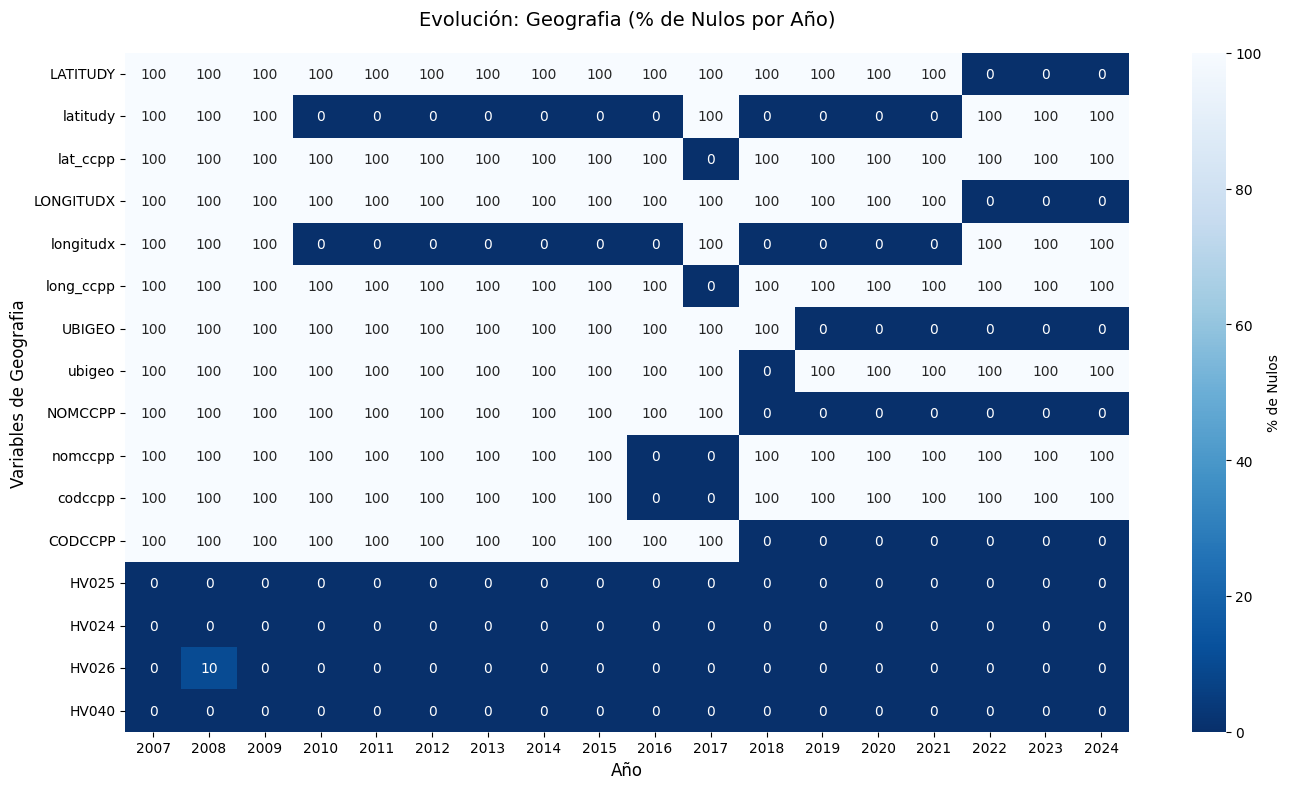

In [26]:
# Analizar Geografía (Azul)
analizar_categoria('geografia', cmap='Blues_r', figsize=(14, 8))

#### Conclusiones del Análisis Geográfico (Resolución de Schema Drift)

**Coordenadas Geográficas (Latitud y Longitud):**
- 2010 a 2016 y 2018 a 2021: Usaron latitudy y longitudx (0% nulos).
- 2017 (El año rebelde): Cambiaron el nombre exclusivamente a lat_ccpp y long_ccpp.
- 2022 a 2024: Empezaron a usar mayúsculas con LATITUDY y LONGITUDX.
- 2007 a 2009: Simplemente no hay coordenadas registradas en esos años (100% de nulos en todas las variantes).

**Código de Ubicación Geográfica (UBIGEO):**
- 2007 a 2017: No incluyeron el UBIGEO (código de 6 dígitos) en este módulo específico. (Nota: No es crítico, porque seguimos teniendo HV024 que es la Región/Departamento, por lo que no perdemos representatividad macro).
- 2018: Lo introdujeron por primera vez en minúsculas como ubigeo.
- 2019 a 2024: Decidieron pasarlo a mayúsculas como UBIGEO.

**Centros Poblados:**
- 2007 a 2015: No se capturaba explícitamente el nombre ni el código del centro poblado en la base de datos pública del módulo de vivienda.
- 2016 y 2017: Se introdujo como nomccpp y codccpp (minúsculas).
- 2018 a 2024: Se estandarizó permanentemente a mayúsculas (NOMCCPP y CODCCPP).

**Estándar Internacional DHS (Demographic and Health Surveys):**
- Variables como HV024 (Región), HV025 (Tipo de área urbana/rural), HV026 (Lugar de residencia) y HV040 (Altitud) son parte del núcleo mundial de la encuesta DHS. Como resultado, están perfectamente estandarizadas y presentan un 0% de nulos en casi toda la historia (con una pequeñísima anomalía del 10% en HV026 para el 2008).


### Categoría de muestreo
|Variable|Label|Nulos|
|--|--|--|
| HV001 | Conglomerado | 0.0% nulos |
| HV004 | Unidad última de muestreo | 0.0% nulos |
| HV005X | Factor de ponderación niño menor de 5 años 2015 | 94.0% nulos |
| HV005A | Sample weight Departamental | 94.0% nulos |
| HV005 | Factor de ponderación | 11.0% nulos |
| hv005 | Factor de ponderacion | 89.5% nulos |
| HV020 | Muestra de alguna vez en union | 0.0% nulos |
| hv022 | Estrato | 94.0% nulos |
| HV022 | Estrato | 6.0% nulos |
| HV021 | Unidad de muestreo primario - conglomerado | 0.0% nulos |
| HV023 | Dominio | 0.0% nulos |
| HV027 | Selección para hombre/esposo | 0.0% nulos |
| HV028 | Peso de muestra masculino | 100.0% nulos |
| HV033 | Ultimate area selection prob. | 89.1% nulos |
| HV042 | Selección para medición de hemoglobina | 0.0% nulos |
| HV043 | Hogares seleccionados para el módulo de mujeres de estado | 0.0% nulos |
| HV044 | Selección para el módulo de violencia familiar | 0.0% nulos |
| nconglome | Número de Conglomerado proveniente del marco | 93.8% nulos |
| NCONGLOME1 | Número de Conglomerado proveniente del marco | 93.9% nulos |
| NCONGLOME | Número de Conglomerado proveniente del marco | 69.2% nulos |


ANÁLISIS DE CATEGORÍA: MUESTREO


year,Etiqueta,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
NCONGLOME1,Número de Conglomerado (proveniente del marco),100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.000000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0
nconglome,Número de Conglomerado (proveniente del marco),100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.000000,100.0,0.0,100.0,100.0,100.0,100.0,100.0,100.0
NCONGLOME,Número de Conglomerado (proveniente del marco),100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.000000,100.0,100.0,0.0,0.0,0.0,0.0,0.0,100.0
HV005X,Factor de ponderación niño menor de 5 años 2015,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0,100.000000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
HV005A,Sample weight Departamental,100.0,0.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.000000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
hv005,Factor de ponderacion,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0,100.0,8.469998,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
HV005,Factor de ponderación,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,100.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
hv022,Estrato,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0.000000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
HV022,Estrato,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV001,Conglomerado,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


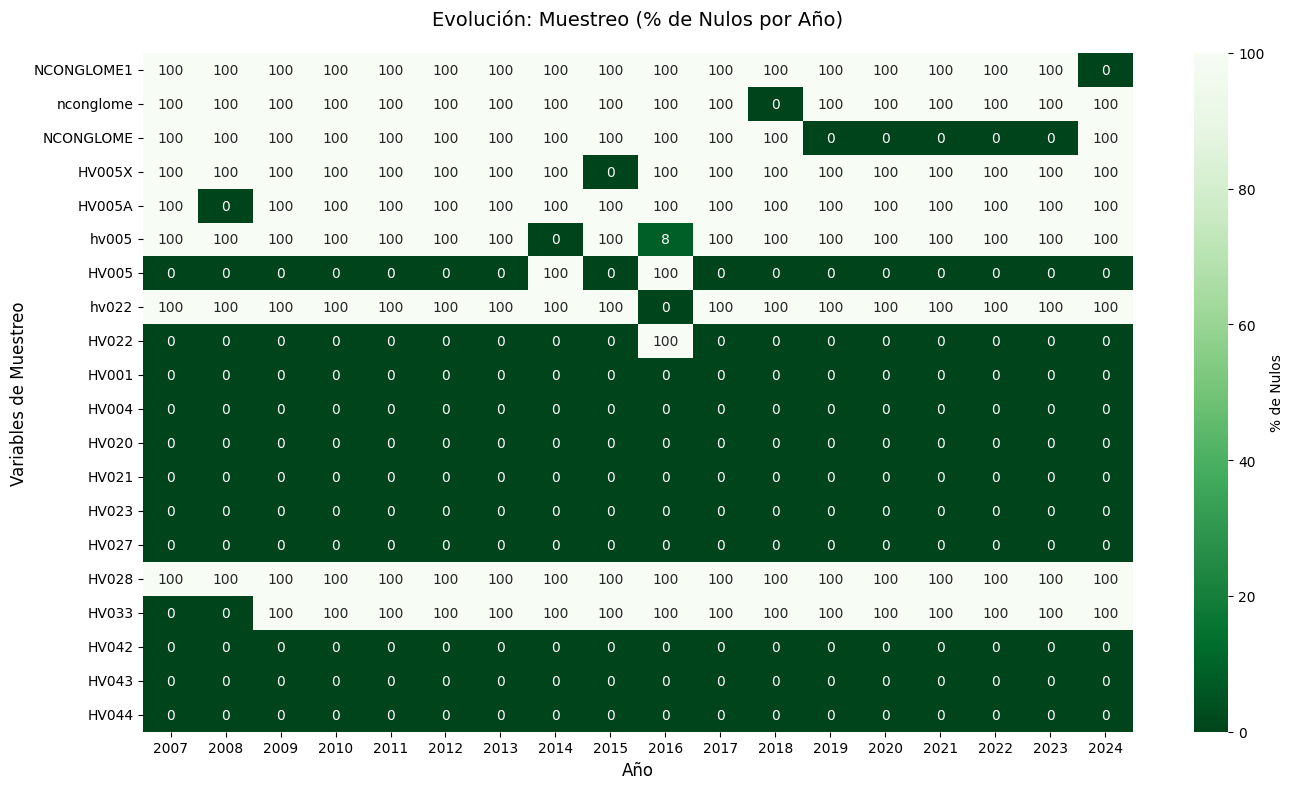

In [27]:
# Analizar Muestreo (Verde)
analizar_categoria('muestreo', cmap='Greens_r', figsize=(14, 8))


#### Conclusiones del Análisis de Muestreo (Resolución de Schema Drift)

**1. Conglomerado Oficial y Unidad de Muestreo (Estándar Internacional DHS):**
- Variables como `HV001` (Conglomerado) y `HV004` (Unidad Última de Muestreo) pertenecen al núcleo del estándar mundial DHS. Son **estables y perfectas**, presentando un **0% de nulos** en toda la ventana histórica (2007-2024). Serán nuestras referencias principales.

**2. Número de Conglomerado del Marco Muestral Peruano (Variable Local INEI):**
El INEI manejó su propia variable de marco muestral, sufriendo de "Schema Drift":
- **2007 a 2017:** No existía en la base pública. *(No afecta, usamos la internacional `HV001`)*.
- **2018:** Se introdujo bajo el nombre `nconglome` (minúsculas).
- **2019 a 2023:** Se estandarizó a mayúsculas como `NCONGLOME`.
- **2024:** Se renombró añadiéndole un número al final, quedando como `NCONGLOME1`.

**3. Factores de Ponderación (Pesos Muestrales):**
- **La variable maestra (`HV005` y `hv005`):** Es el factor de expansión oficial usado casi todos los años (0% nulos). En **2014 y 2016**, el INEI registró este peso en minúsculas (`hv005`). *(Curiosamente, en 2016 este peso arrojó un 8.47% de nulos).*
- **Pesos Especiales Temporales:**
  - `HV005A` (2008): Factor alternativo a nivel "Departamental".
  - `HV005X` (2015): Factor calibrado exclusivamente para "Niños menores de 5 años".

**4. Unidades de Diseño (Estrato, Dominio y Selección):**
- **El núcleo perfecto:** Las variables `HV020`, `HV021` (Unidad de Muestreo Primario / PSU), `HV023` (Dominio de Estrato) y `HV027` (Selección de hombres) se mantienen **impecables con 0% de nulos** de principio a fin.
- **El caso del Estrato (`HV022` y `hv022`):** Es la variable oficial usada todos los años. Sin embargo, exclusivamente en **2016** se registró en minúsculas como `hv022`.

**5. Módulos de Selección Específica y Variables Descartables:**
- Las variables que indican si el hogar fue seleccionado para un submódulo específico (`HV042` para Hemoglobina, `HV043` para Estado de la mujer, y `HV044` para Violencia Familiar) son estándar y presentan un **0% de nulos**.
- **Variables Descartables (Eliminación Segura):**
  - `HV028` (Peso de muestra masculino): Tiene **100% de nulos** en toda la historia (la ENDES en Perú se enfoca en MEF y niños).
  - `HV033` (Probabilidad de selección de área): Fue requerida solo en **2007 y 2008**, y desapareció por completo después.

### Categoría administrativa
| Variables | Etiqueta | Nulos |
|--|--|--|
| ID1 | Año | 27.6% nulos |
| year | Año | 0.0% nulos |
| HHID | Identificacion Cuestionario del Hogar | 0.0% nulos |
| HV000 | Código del país | 0.0% nulos |
| HV002 | Vivienda | 0.0% nulos |
| HV002A | Hogar | 24.5% nulos |
| HV003 | Número de orden del Informante del cuestionario | 0.0% nulos |
| HV006 | Month of interview | 43.1% nulos |
| HV007 | Año de entrevista | 6.2% nulos |
| HV008 | Fecha de entrevista meses - CMC | 0.0% nulos |
| HV015 | Resultado de la entrevista en el hogar | 0.0% nulos |
| HV016 | Day of interview | 43.1% nulos |
| HV017 | Número de visitas | 0.0% nulos |
| HV018 | Interviewer identification | 43.1% nulos |
| HV019 | Keyer identification | 46.6% nulos |
| HV030 | Supervisor de campo | 0.0% nulos |
| HV031 | Editor de campo | 100.0% nulos |
| HV032 | Editor de la oficina | 0.0% nulos |


ANÁLISIS DE CATEGORÍA: ADMINISTRATIVA


year,Etiqueta,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
year,Sin etiqueta,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ID1,Año,100.0,100.0,100.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,100.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0
HV002,Vivienda,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV002A,Hogar,100.0,100.0,100.000000,100.0,100.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HHID,Identificacion Cuestionario del Hogar,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV000,Código del país,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV003,Número de orden del Informante del cuestionario del hogar,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV008,Fecha de entrevista meses (CMC),0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV019,Keyer identification,0.0,0.0,0.000000,0.0,0.0,0.0,69.947747,4.011726,0.000000,0.0,0.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
HV016,Day of interview,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.003294,0.002725,0.0,0.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0


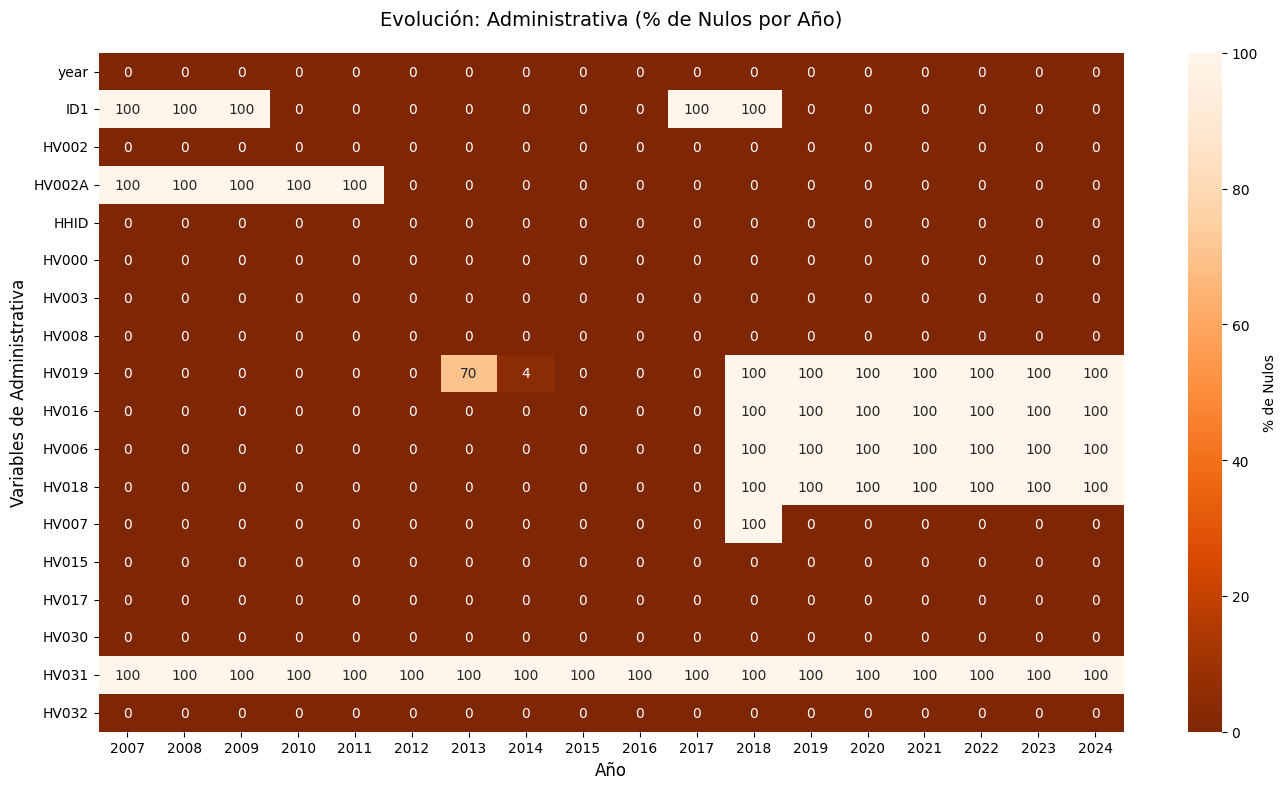

In [28]:
# Analizar Administrativa (Naranja)
analizar_categoria('administrativa', cmap='Oranges_r', figsize=(14, 8))


#### Conclusiones del Análisis de Variables Administrativas

**1. Identificadores Básicos (La Llave Maestra):**
- Las variables `HHID` (Identificador alfanumérico único del hogar), `HV000` (Código del país) y `HV002` (Número de Vivienda) son el núcleo de la DHS y presentan un **0% de nulos** histórico (2007-2024). 
- `HV002A` (Número de Hogar dentro de la vivienda) fue introducida recién en el 2012. No nos afecta, ya que el `HHID` es la *Primary Key* suficiente para identificar cada hogar en los cruces de la Fase 3.

**2. Cronología y Fechas de Entrevista:**
- **La variable matemática:** `HV008` (Fecha CMC - Century Month Code) y nuestro `year` inyectado tienen 0% nulos, dándonos la cronología perfecta de la entrevista.
- **Mes (`HV006`) y Día (`HV016`):** Estas sufrieron un "apagón de privacidad" a partir de 2018 (100% nulos). Conservaremos el mes (`HV006`) por registro histórico para los años donde sí existe (2007-2017).
- **Año original (`HV007`):** Por algún motivo de esquema, el año original de la encuesta fue omitido de esta columna exclusivamente en el 2018 (100% nulos), pero está presente (0% nulos) en todos los demás años. La conservaremos.

**3. Variables de Control de Campo y Personal:**
- **El Informante (`HV003`):** El "Número de orden del Informante" está **perfectamente documentado con 0% de nulos** histórico. Siempre sabremos qué miembro del hogar fue el que contestó el cuestionario.
- `HV015` (Resultado final), `HV017` (Número de visitas), `HV030` (Supervisor) y `HV032` (Editor de oficina) están casi perfectas (~0% nulos).
- **Anonimización del Personal:** Los identificadores del equipo de campo (`HV018` Entrevistador y `HV019` Digitador) fueron censurados permanentemente por el INEI desde el 2018.
- `HV031` (Editor de campo) es insalvable, jamás fue recopilada (100% nulos histórico).

***

##### Limpieza de la Categoría Administrativa (Ajustada)

Y aquí tienes el código actualizado, donde he sacado a `HV006` y `HV007` de la lista de eliminación para que las conservemos intactas en tu DataFrame.

```python
# 12. Eliminación de Variables Administrativas Inútiles o Anonimizadas
# Conservamos HV003, HV006 y HV007 completas en el dataset.
columnas_a_borrar_admin = [
    'ID1',      # Año redundante (ya tenemos nuestro 'year' y 'HV007')
    'HV016',    # Día anonimizado permanentemente desde 2018 
    'HV018',    # ID Entrevistador anonimizado desde 2018
    'HV019',    # ID Digitador anonimizado desde 2018
    'HV031'     # Editor de campo (100% nulos)
]

# Solo eliminamos las que realmente existan en el dataframe
columnas_a_borrar_admin = [col for col in columnas_a_borrar_admin if col in df_rech0.columns]
df_rech0.drop(columns=columnas_a_borrar_admin, inplace=True)

print(f"Se eliminaron {len(columnas_a_borrar_admin)} variables administrativas insalvables.")
```

### Categoría de demografia
| Variables | Etiqueta | Nulos |
|--|--|--|
| HV009 | Total de personas en el hogar | 0.0% nulos | 
| HV010 | Número de mujeres elegibles para entrevista individual | 0.0% nulos | 
| HV011 | Número de hombres elegibles por hogar | 0.0% nulos | 
| HV012 | Número de miembros de jure - residentes habituales | 0.0% nulos | 
| HV013 | Número de miembros de facto - pernoctaron | 0.0% nulos | 
| HV014 | Número de niños menores de 5 años | 0.0% nulos | 
| HV035 | Número de niños elegibles para altura y peso | 0.0% nulos | 
| HV041 | Número de mujeres con medición de peso y talla | 0.0% nulos | 



ANÁLISIS DE CATEGORÍA: DEMOGRAFIA


year,Etiqueta,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
HV009,Total de personas en el hogar,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV010,Número de mujeres elegibles para entrevista individual,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV011,Número de hombres elegibles por hogar,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV012,Número de miembros de jure (residentes habituales),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV013,Número de miembros de facto (personas que durmieron la noche anterior),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV014,Número de niños menores de 5 años,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV035,Número de niños elegibles para altura y peso,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV041,Número de mujeres con medición de peso y talla,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


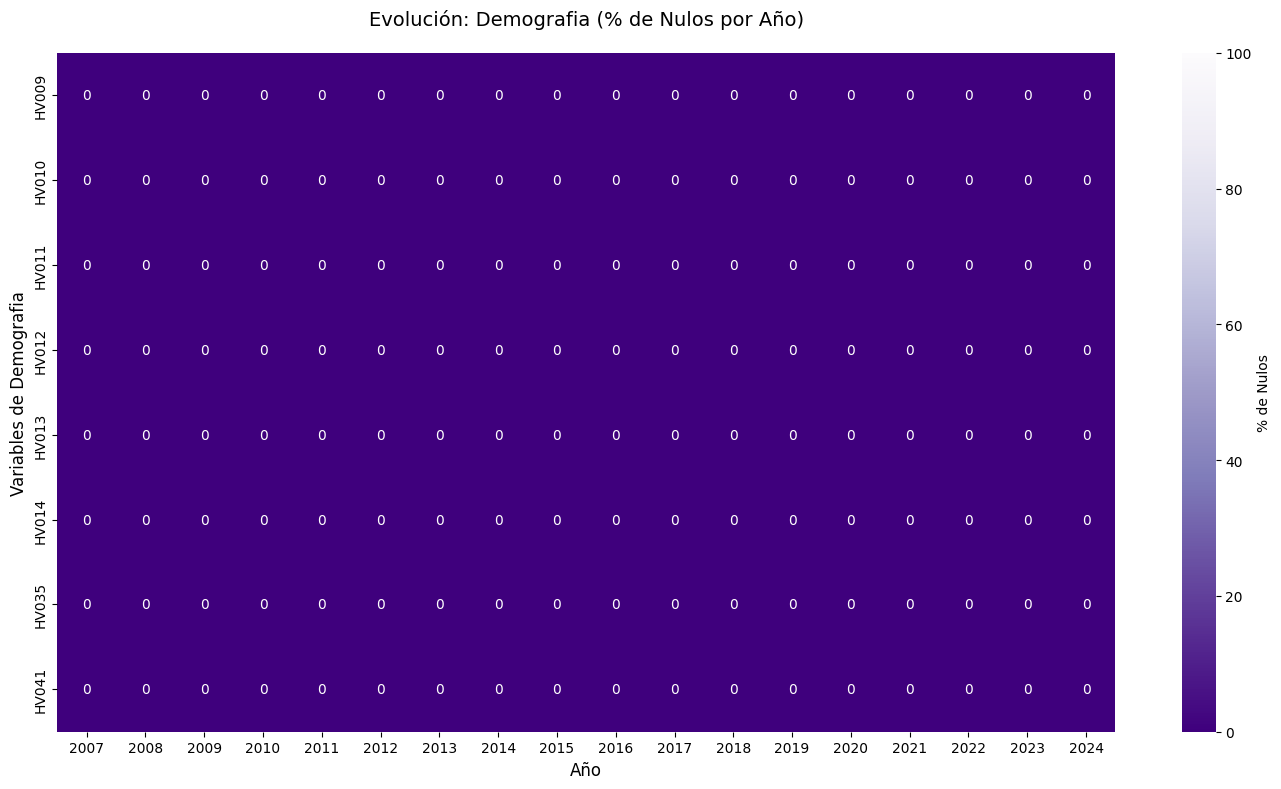

In [29]:
# Analizar Demografía (Morado)
analizar_categoria('demografia', cmap='Purples_r', figsize=(14, 8))

#### Conclusiones del Análisis de Variables Demográficas

**El Núcleo Sagrado de la ENDES (0% Nulos Histórico):**
La categoría demográfica es absolutamente perfecta. Todas las variables clave para el conteo y filtro de nuestra población objetivo se mantienen intactas y completas desde el 2007 hasta el 2024, sin sufrir ningún tipo de alteración de nombres ni censura:
- `HV009`: Total de personas en el hogar.
- `HV012` y `HV013`: Miembros residentes habituales (de jure) y miembros que pernoctaron (de facto).
- **Población Objetivo:** `HV010` (Mujeres elegibles) y `HV014` (Niños menores de 5 años).
- **Filtros Antropométricos:** `HV035` (Niños elegibles para medición) y `HV041` (Mujeres medidas).

*Conclusión Técnica:* No se requiere absolutamente ninguna limpieza, consolidación ni eliminación en este bloque. Las variables están listas para ser usadas en cualquier modelo predictivo o filtro poblacional.

## Análisis de Contenido Real: Verificación de Identificadores y Valores

In [30]:
duplicados_hhid = df_rech0.duplicated(subset=['year', 'HHID']).sum()
print(f"✅ Duplicados en HHID: {duplicados_hhid}" if not duplicados_hhid else f"⚠️ Duplicados en HHID: {duplicados_hhid}")

duplicados_sec = df_rech0[df_rech0.duplicated(subset=['year', 'HV001', 'HV002'], keep=False)]
if duplicados_sec.empty:
    print("✅ Combinación HV001 + HV002 es única.")
else:
    print(f"⚠️ Se encontraron {len(duplicados_sec)} viviendas con múltiples hogares (desempatados por HV002A).")
    cols = ['year', 'HHID', 'HV001', 'HV002', 'HV002A']
    df_show = duplicados_sec[cols].sort_values(by=['year', 'HV001', 'HV002']).head(5)
    df_show = df_show.rename(columns={c: f"{c} ({diccionario.get(c, c)})" for c in ['HV001', 'HV002', 'HV002A']})
    display(df_show)

✅ Duplicados en HHID: 0
⚠️ Se encontraron 15239 viviendas con múltiples hogares (desempatados por HV002A).


,year,HHID,HV001 (Conglomerado),HV002 (Vivienda),HV002A (Hogar)
149475,2012,001106401,11.0,64.0,1.0
149476,2012,001106402,11.0,64.0,2.0
149684,2012,002002201,20.0,22.0,1.0
149685,2012,002002202,20.0,22.0,2.0
149699,2012,002009001,20.0,90.0,1.0


**Conclusiones de la Verificación de Identificadores (Primary Keys)**

1. **`✅ Duplicados en HHID: 0` (La victoria técnica)**: El identificador principal (`HHID`) es 100% único por año. Esto nos garantiza que el INEI ha mantenido una arquitectura robusta y que podemos usar `HHID` como nuestra llave maestra para cruzar datos con otros módulos (madres, niños) sin miedo a generar productos cartesianos o mezclar familias.

2. **`⚠️ 15239 viviendas con múltiples hogares` (Realidad socioeconómica)**: Que la combinación de Conglomerado (`HV001`) y Vivienda (`HV002`) se repita no es un error de los datos. En el contexto peruano es muy común que varias familias compartan la misma estructura física (ej. padres en el primer piso e hijos en el segundo), pero tengan "ollas" (presupuestos de comida) separadas.
- La metodología DHS maneja esto perfectamente asignando `HV002A` (Número de Hogar) para desempatarlos.
- **Regla de Oro**: Jamás cruzar tablas usando únicamente `HV001` + `HV002`. Siempre debemos usar el `HHID` completo.

### Análisis de Distribución y Valores Atípicos (Anomalías de Encuesta)

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Columnas que no tiene sentido analizar estadísticamente
cols_excluir = ['year', 'ID1', 'HV000', 'HV001', 'HV002', 'HV002A', 'HV003', 'nconglome']

def analizar_distribucion_y_atipicos(nombre_categoria):
    """
    Genera la tabla descriptiva y los boxplots para una categoría específica.
    """
    vars_cat = categorias.get(nombre_categoria, [])
    existentes = [v for v in vars_cat if v in df_rech0.columns]
    
    # Extraer solo las numéricas
    cols_numericas = df_rech0[existentes].select_dtypes(include=['number']).columns.tolist()
    cols_finales = [c for c in cols_numericas if c not in cols_excluir]
    
    if not cols_finales:
        print(f"No hay variables numéricas válidas para la categoría: {nombre_categoria}")
        return
        
    print(f"{'='*50}")
    print(f"  DISTRIBUCIÓN Y ATÍPICOS: {nombre_categoria.upper()}")
    print(f"{'='*50}")
    
    # 1. Tabla Estadística
    desc_df = df_rech0[cols_finales].describe().T
    desc_df.insert(0, 'Etiqueta', [diccionario.get(col, 'Sin etiqueta') for col in desc_df.index])
    display(desc_df)
    
    # 2. Gráficos de Boxplot por cada variable
    n_vars = len(cols_finales)
    cols_grid = 3
    rows_grid = math.ceil(n_vars / cols_grid)
    
    fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(15, 4 * rows_grid))
    
    # Asegurar que axes sea iterable
    if n_vars == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
        
    for i, col in enumerate(cols_finales):
        data_to_plot = df_rech0[col].dropna()
        if not data_to_plot.empty:
            sns.boxplot(y=data_to_plot, ax=axes[i], color="skyblue")
        else:
            axes[i].text(0.5, 0.5, 'Sin datos válidos (100% nulos)', ha='center', va='center', color='red')
            
        label = str(diccionario.get(col, col) or col)
        label_trunc = label[:35] + '...' if len(label) > 35 else label
        axes[i].set_title(f"{col}\n{label_trunc}", fontsize=10)
        axes[i].set_ylabel("")
        
    # Eliminar gráficos vacíos que sobran en la grilla
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()


**Conclusiones de Valores Atípicos y Distribución**

1. **Ausencia de Códigos de Error (99/999)**: Los valores máximos son completamente lógicos. No hay un hogar con "99" niños (que normalmente es el código DHS para 'no sabe/no responde'). El máximo de niños menores de 5 años es 10, y el máximo de personas en un hogar es 24.
2. **Altitud Realista (`HV040`)**: El rango de altitud va de 0 a 5,053 metros. Esto es perfectamente consistente con la geografía peruana (La Rinconada está a ~5,100 msnm), lo que confirma que no usaron un código "9999" para omitir datos.
3. **El Misterio de `HV011`**: El número de hombres elegibles está en absoluto cero (media 0, max 0). Esto confirma que el enfoque de los módulos que usaremos está estrictamente dirigido a la salud materno-infantil.
4. **Hogares Vacíos (`HV009 = 0`)**: Existen registros con 0 habitantes. Estos corresponden típicamente a viviendas seleccionadas que resultaron estar desocupadas, destruidas o donde hubo rechazo a la entrevista (algo que se puede filtrar cruzando con `HV015` - Resultado de la entrevista).

  DISTRIBUCIÓN Y ATÍPICOS: GEOGRAFIA


,Etiqueta,count,mean,std,min,25%,50%,75%,max
LATITUDY,NaN,112226.0,-10.758604,3.885586,-18.328269,-13.408184,-11.870090,-7.262110,-1.373493
latitudy,Latitud del conglomerado,366387.0,-10.822970,3.949061,-79.514688,-13.522580,-11.878314,-7.338411,0.000000
lat_ccpp,Latitud,36595.0,-10.747913,3.922273,-18.242419,-13.426918,-11.872806,-7.159049,-2.562590
LONGITUDX,NaN,112226.0,-75.538900,3.112664,-81.307072,-77.597294,-76.216162,-73.331344,-69.007142
longitudx,Longitud del conglomerado,366387.0,-75.428270,3.339461,-81.307072,-77.604700,-76.139530,-73.244750,0.000000
long_ccpp,Longitud,36595.0,-75.508085,3.144483,-81.305605,-77.600490,-76.190284,-73.248296,-68.854092
HV025,Área de residencia,608995.0,1.368233,0.482325,1.000000,1.000000,1.000000,2.000000,2.000000
HV024,Región,608995.0,13.071818,6.984482,1.000000,7.000000,14.000000,19.000000,25.000000
HV026,Lugar de residencia,605258.0,1.843961,1.045568,0.000000,1.000000,2.000000,3.000000,3.000000
HV040,Altitud del conglomerado en metros,608995.0,1452.144691,1490.562789,0.000000,120.000000,585.000000,3009.000000,5053.000000


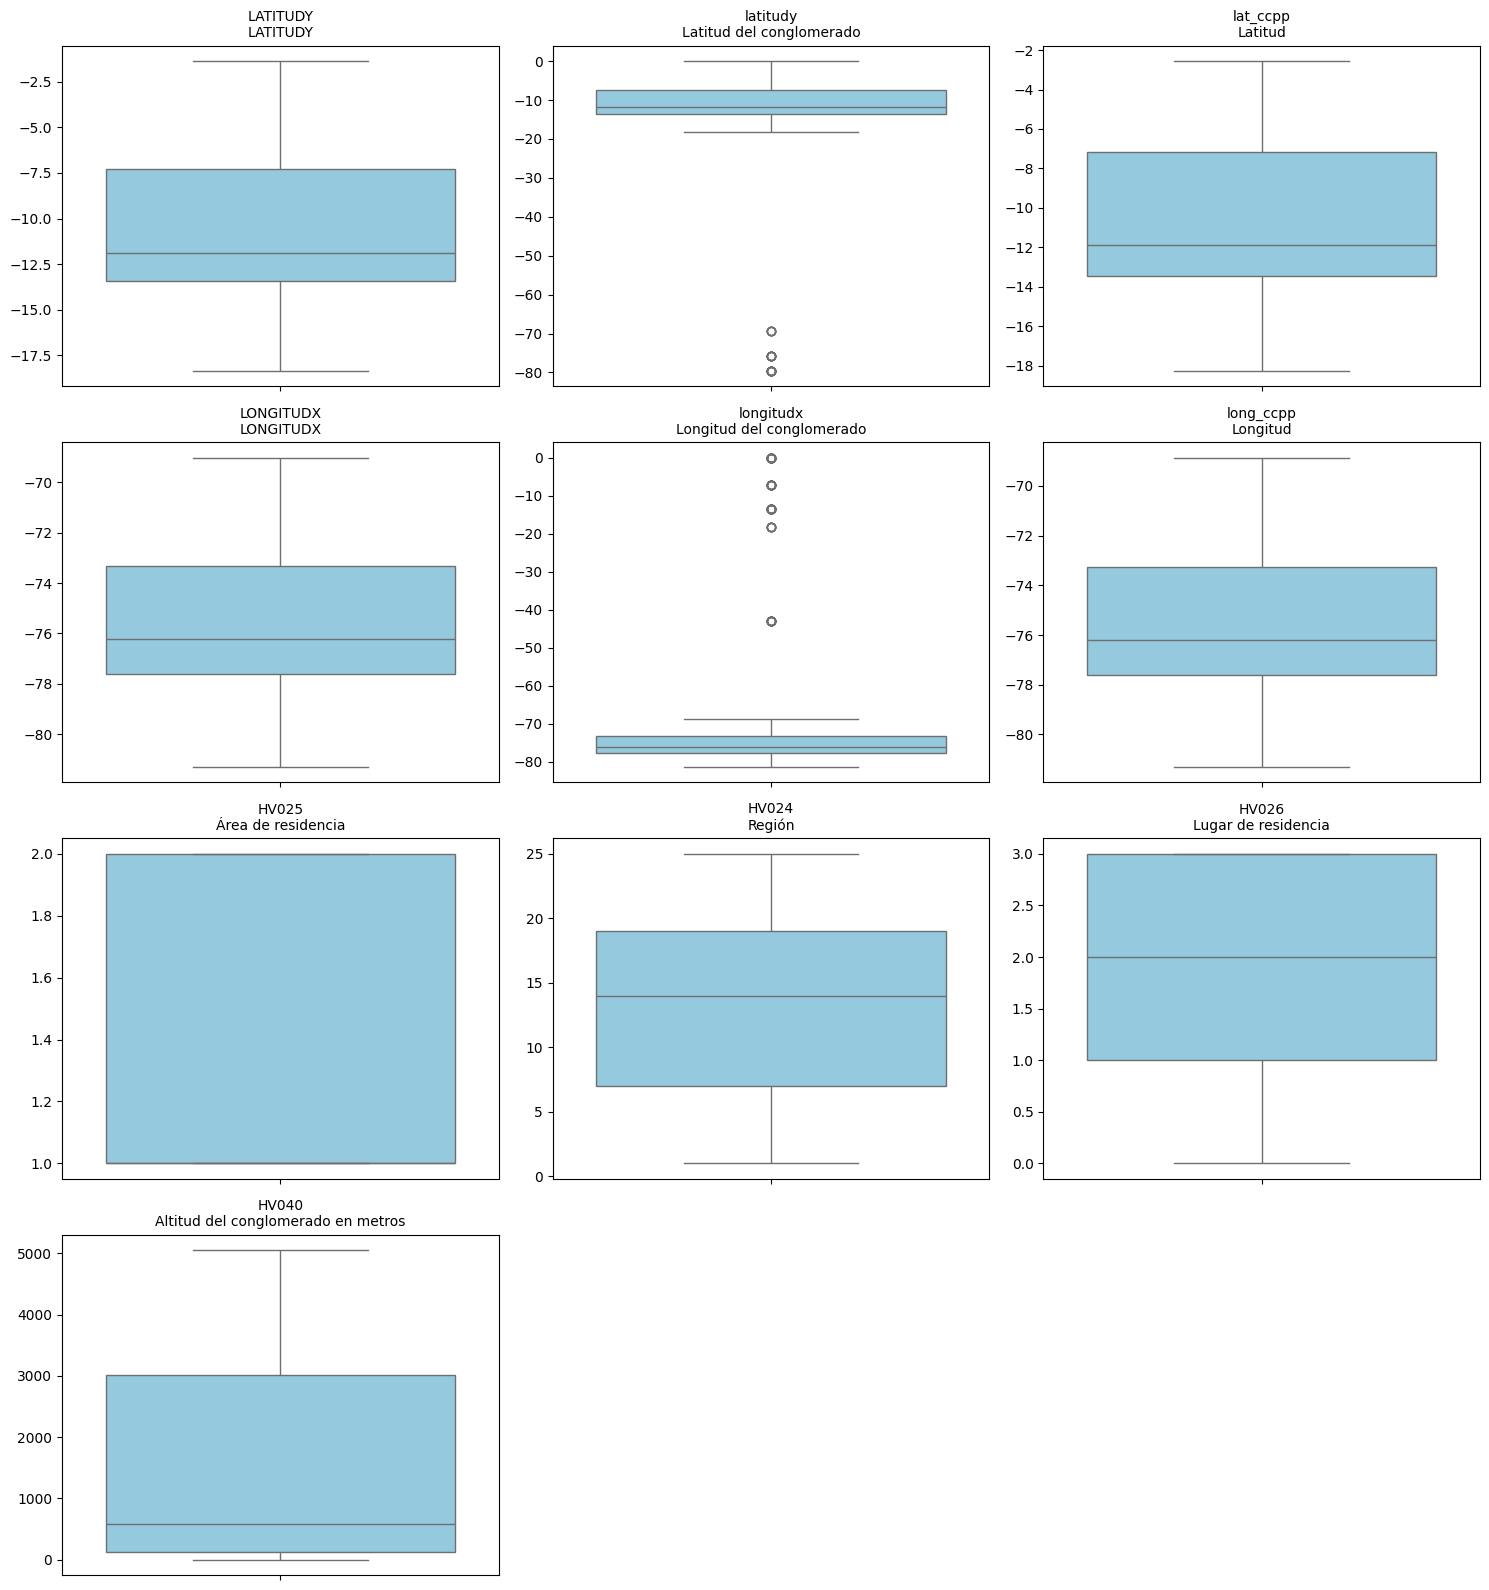

In [34]:
analizar_distribucion_y_atipicos('geografia')

### Conclusiones
#### Variables Geográficas (Latitud)

* **`LATITUDY`**, **`latitudy`** y **`lat_ccpp`** presentan una media consistente, alrededor de `-10.7` a `-10.8`.
* **Valores atípicos en `latitudy`**: Esta variable presenta un mínimo extremo de `-79.51` (un claro error de registro, probablemente un valor de longitud invertido) y un máximo de `0.00`.
* **Consistencia espacial**: Los rangos de **`LATITUDY`** (de `-18.32` a `-1.37`) y **`lat_ccpp`** (de `-18.24` a `-2.56`) son coherentes con las coordenadas reales para Perú.
* **Volumen de datos**: **`latitudy`** es la variable con mayor cobertura (366,387 registros), seguida de **`LATITUDY`** (112,226) y **`lat_ccpp`** (36,595).
* **Acción para limpieza**: Se recomienda utilizar **`latitudy`** como base por su mayor volumen de datos, pero aplicando un filtro estricto (ej. mantener solo valores entre `-19.0` y `-1.0`) para anular los atípicos, o cruzar con la longitud para verificar si las coordenadas se invirtieron por error.

#### Variables Geográficas (Longitud)

* **`LONGITUDX`**, **`longitudx`** y **`long_ccpp`** presentan una media consistente, alrededor de `-75.4` a `-75.5`.
* **Valores atípicos en `longitudx`**: Al igual que en su contraparte de latitud, presenta un valor máximo anómalo de `0.00` (típicamente usado como relleno cuando no se registró la coordenada). El valor mínimo (`-81.3`) es normal.
* **Consistencia espacial**: Los rangos de **`LONGITUDX`** y **`long_ccpp`** (aprox. de `-81.3` a `-68.8`) son perfectamente coherentes con las coordenadas reales de longitud para el territorio peruano.
* **Volumen de datos**: Se mantiene el patrón de completitud; **`longitudx`** es la variable dominante con 366,387 registros, por encima de **`LONGITUDX`** (112,226) y **`long_ccpp`** (36,595).
* **Acción para limpieza**: Se debe usar **`longitudx`** como variable principal, pero aplicando un filtro de contención espacial (ej. mantener solo valores entre `-82.0` y `-68.0`) para eliminar los casos con `0.00`. Asimismo, al cruzar con la latitud, revisar si hay coordenadas invertidas recordando el valor de `-79.51` que se infiltró previamente en `latitudy`.

#### Variables de Clasificación Geográfica y Residencial

* **`HV025` (Área de residencia)** y **`HV024` (Región)**: Muestran una cobertura completa y uniforme (608,995 registros). Sus rangos son correctos: `HV025` es binaria (1 a 2, típico para clasificación Urbano/Rural) y `HV024` va del 1 al 25, coincidiendo exactamente con el número de departamentos de Perú.
* **`HV026` (Lugar de residencia)**: Variable con 4 categorías (valores del 0 al 3). Presenta una ligera pérdida de datos (605,258 registros frente a los 608,995 del resto).
* **Acción para limpieza**: Es recomendable convertir estas tres variables a formato categórico (ej. tipo `category` o enteros de 8 bits) para ahorrar memoria. Para **`HV026`**, habrá que decidir si imputar la pequeña cantidad de valores faltantes (~3,700) o mantenerlos como nulos.

#### Variables Topográficas (Altitud)

* **`HV040` (Altitud del conglomerado)**: Presenta también una cobertura completa de 608,995 registros.
* **Consistencia topográfica**: El rango reportado va desde `0` hasta `5,053` metros sobre el nivel del mar, con una media de `1,452` metros. Estos valores son estructuralmente lógicos y coherentes con la compleja geografía peruana.
* **Acción para limpieza**: La variable está limpia y sin atípicos fuera de límite. Solo se sugiere una revisión rápida a los valores `0` para asegurar que representan ciudades costeras (ej. Callao) y no valores faltantes rellenados. Se puede optimizar pasándola a un tipo numérico ligero (`int16`).


  DISTRIBUCIÓN Y ATÍPICOS: MUESTREO


,Etiqueta,count,mean,std,min,25%,50%,75%,max
HV005X,Factor de ponderación niño menor de 5 años 2015,36692.0,458210.195574,4.215431e+05,0.0,173166.00,363006.0,578707.0,4651036.0
HV005A,Sample weight Departamental,36742.0,948576.504083,9.863532e+05,0.0,356396.00,652463.0,1366282.0,4050427.0
hv005,Factor de ponderacion,63904.0,975744.864109,1.085106e+06,0.0,346404.75,654915.0,1231552.0,16378944.0
HV005,Factor de ponderación,541987.0,930700.382581,1.271628e+06,0.0,243441.00,529713.0,1128627.0,34442965.0
hv022,Estrato,36647.0,1.940432,8.587867e-01,1.0,1.00,2.0,3.0,3.0
HV022,Estrato,572348.0,85.336058,1.043106e+02,0.0,15.00,42.0,141.0,706.0
HV004,Unidad última de muestreo,608995.0,1799.356885,1.360290e+03,1.0,739.00,1550.0,2531.0,7057.0
HV020,Muestra de alguna vez en union,608995.0,0.000000,0.000000e+00,0.0,0.00,0.0,0.0,0.0
HV021,Unidad de muestreo primario (conglomerado),608995.0,1799.356885,1.360290e+03,1.0,739.00,1550.0,2531.0,7057.0
HV023,Dominio,608995.0,13.071818,6.984482e+00,1.0,7.00,14.0,19.0,25.0


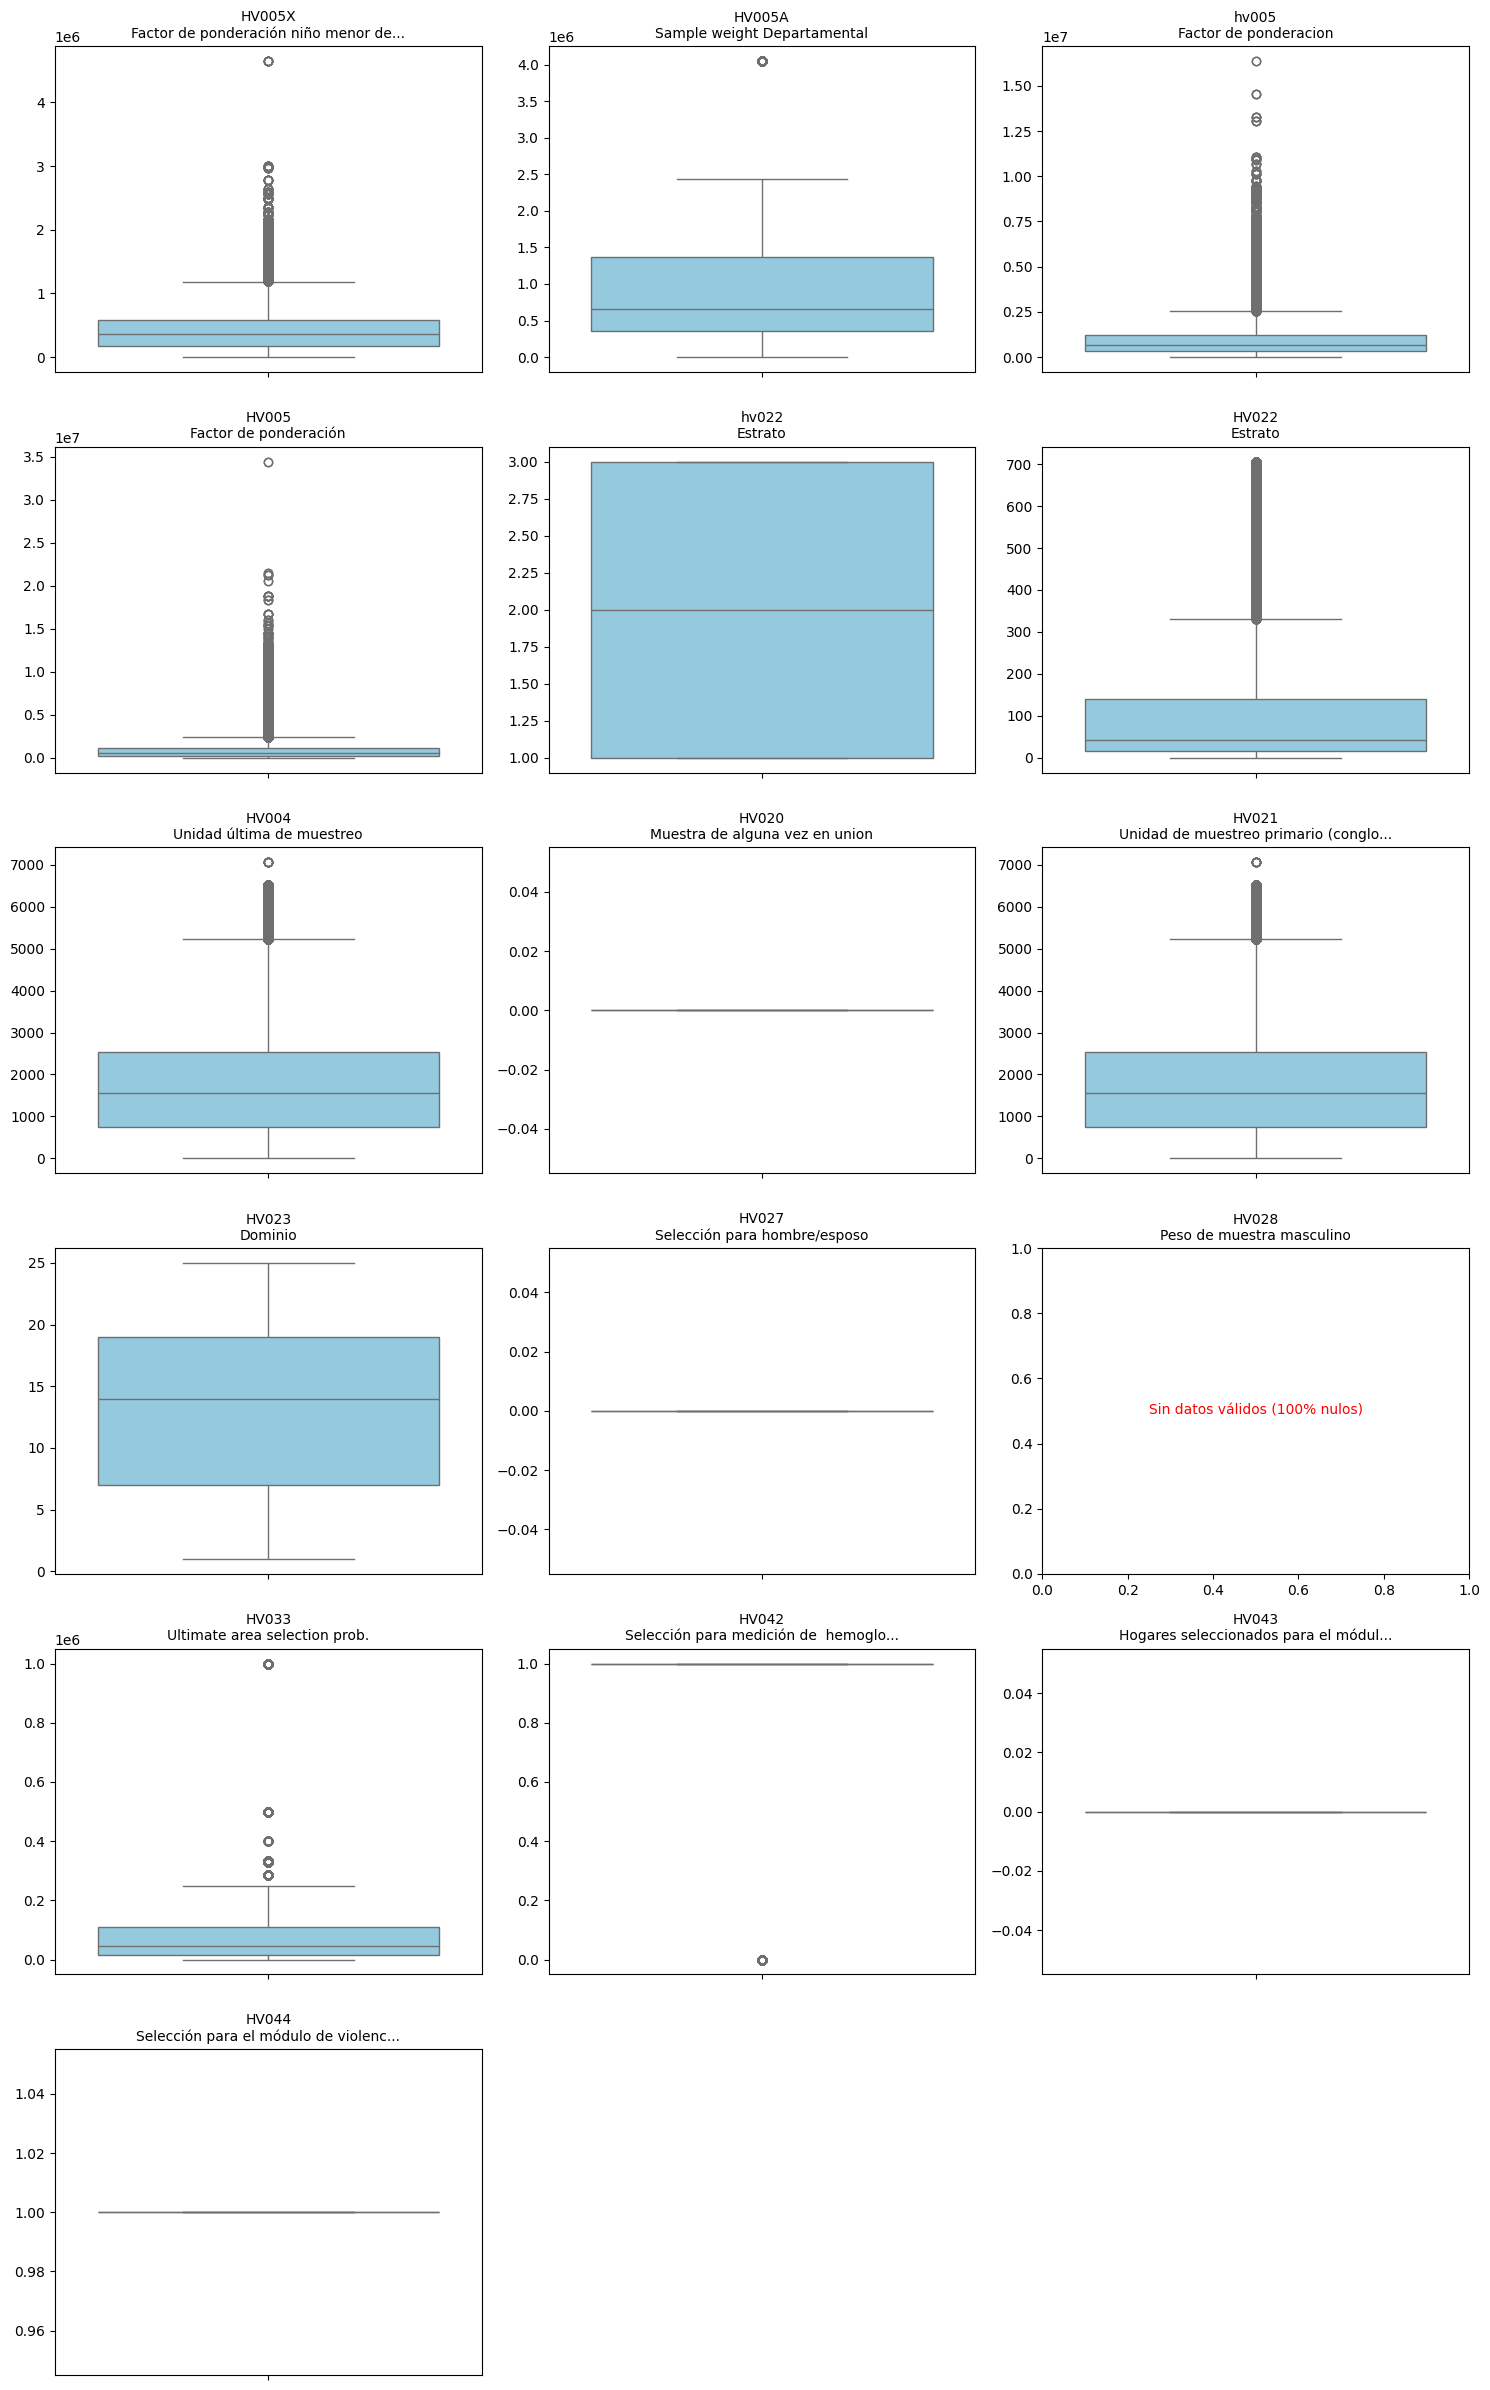

In [41]:
analizar_distribucion_y_atipicos('muestreo')

### Conclusiones: Variables de Muestreo (Factores de Ponderación)

* **Multiplicidad de factores**: La base contiene distintos factores de expansión que se aplican según el diseño del estudio o el nivel de agregación:
    * **`HV005` y `hv005` (Factor general del hogar)**: Son los pesos estándar. `HV005` es la principal (541,987 registros) y `hv005` parece ser la misma variable pero leída de años/archivos donde estaba en minúscula (63,904 registros). 
    * **`HV005A` (Departamental)**: Peso estadístico calibrado específicamente para obtener representatividad a nivel de región/departamento.
    * **`HV005X` (Niños < 5 años, 2015)**: Un peso altamente específico para análisis de población infantil en un año puntual.
* **Escala decimal implícita**: Los valores máximos llegan al orden de los millones (ej. 34,442,965 en `HV005`). Esto es propio del formato DHS/ENDES, el cual **guarda los pesos sin punto decimal, usando 6 decimales implícitos** (un valor en la base de `1,000,000` equivale a un peso real de `1.0`).
* **Mínimos en cero**: Todas registran un mínimo de `0.0`, lo que normalmente se le asigna a encuestas o individuos que no aplican para la submuestra que representa ese factor.
* **Acción para limpieza**: 
    * **Consolidación**: Se deben unificar **`HV005`** y **`hv005`** en una sola columna para tener el peso general continuo a lo largo de todos los años.
    * **Transformación matemática**: Es un paso estricto **dividir los valores entre `1,000,000`** antes de utilizarlos en cualquier modelo o análisis de expansión.
    * **Selección analítica**: Dependiendo del objetivo (ej. si mides desnutrición en niños vs. características del hogar a nivel nacional), deberás elegir dinámicamente qué factor usar y descartar el resto para evitar confusiones.

### Conclusiones: Variables de Diseño Muestral (Estratificación y Conglomerados)

* **`HV022` y `hv022` (Estrato Muestral)**: Identifican el estrato estadístico usado para el diseño de la encuesta. Están separadas por mayúsculas/minúsculas.
    * **Inconsistencia de codificación:** `hv022` tiene valores simples del `1` al `3`, mientras que `HV022` tiene rangos del `0` al `706`. Esto evidencia que la ENDES cambió su metodología de estratificación a lo largo de los años (pasando de estratos simples a estratos complejos que probablemente cruzan departamento por zona urbano/rural).
* **`HV004` (Unidad última) y `HV021` (Unidad primaria - PSU)**: Si observas los estadísticos, ambas tienen **exactamente los mismos números** (mínimo `1`, máximo `7,057`, media `1,799.35`). En la metodología operativa de la ENDES, la unidad primaria suele coincidir con el conglomerado final, convirtiéndolas en columnas idénticas.
* **`HV020` (Muestra alguna vez en unión)**: Es una **variable constante**. Su media, desviación estándar, mínimo y máximo son `0.0`. Esto significa que todos los 608,995 registros tienen un cero, por lo que carece de varianza.
* **Acción para limpieza**: 
    * **`HV020`**: **Eliminar (dropear) obligatoriamente**. Una variable constante (varianza cero) no tiene ningún valor analítico ni matemático para los modelos.
    * **`HV004` y `HV021`**: Al ser columnas duplicadas absolutas, **se recomienda eliminar una de ellas**. La que conserves (generalmente `HV021`) funciona como identificador de clúster, y debe ser tratada como tipo texto/categórica al igual que `nconglome`.
    * **`HV022` / `hv022`**: Deben consolidarse en una sola. Si vas a usar librerías avanzadas para declarar el "diseño muestral complejo" en tus modelos, tendrás que ver cómo armonizar los años que usaron del 1 al 3 con los que usaron hasta el 706. Si solo usarás los factores de ponderación simples (`HV005`), el estrato no te será tan crítico.

### Conclusiones: Variables de Diseño Muestral (Dominios y Probabilidades)

* **`HV023` (Dominio)**: Representa el dominio de estimación estadística. Si observas sus métricas (mínimo `1`, máximo `25`, media `13.07`), notarás que son **idénticas a la variable `HV024` (Región)** que analizamos antes. En la ENDES de Perú, los dominios representativos suelen coincidir exactamente con los 25 departamentos.
* **`HV027` (Selección para hombre/esposo)**: Es otra **variable constante**. Todos los 608,995 registros reportan el valor `0.0`, lo que indica que en este conjunto de datos no se aplicó un submódulo de encuestas exclusivas para varones.
* **`HV028` (Peso de muestra masculino)**: En consecuencia directa a lo anterior, esta variable está **completamente vacía** (100% de nulos o `NaN`), ya que no hay hombres seleccionados que ponderar.
* **`HV033` (Probabilidad de selección del área última)**: Es una probabilidad matemática de selección que solo está presente en 66,078 registros. Al igual que el peso `HV005`, su valor máximo es `1,000,000`, lo que confirma que está **guardada con 6 decimales implícitos** (es decir, `1,000,000` representa una probabilidad del `100%` o `1.0`).
* **Acción para limpieza**: 
    * **`HV027` y `HV028`**: **Eliminar (dropear) obligatoriamente**. Una está llena de ceros (varianza cero) y la otra no tiene datos. No sirven de nada.
    * **`HV023`**: Dado que es un duplicado matemático y conceptual de `HV024` (Región), **se recomienda eliminarla** para evitar redundancias en los modelos.
    * **`HV033`**: En la gran mayoría de análisis, el factor de expansión principal (`HV005`) ya engloba estas probabilidades. Sumado a que `HV033` tiene un ~90% de datos nulos, lo más sensato es **eliminarla**. Si excepcionalmente decides usarla, debes dividir sus valores entre `1,000,000`.



### Conclusiones: Variables de Diseño Muestral (Selección de Módulos)

* **`HV042` (Selección para medición de hemoglobina)**: Es una variable binaria (valores `0` y `1`) con cobertura total en la base. Su media (`0.963`) nos indica que casi el **96.3% de los registros fueron seleccionados** para la prueba de anemia. Dado que tu proyecto es sobre desnutrición, esta variable resulta fundamental.
* **`HV043` (Hogares para módulo de mujeres de estado)**: Es una **variable constante en ceros**. Todos sus estadísticos indican `0.0`, confirmando que este submódulo no tiene datos aplicados en la base que estás procesando.
* **`HV044` (Selección para violencia familiar)**: Es una **variable constante en unos**. Su media, mínimo y máximo son `1.0`. Indica que supuestamente a toda la base se le aplicó el módulo, por lo que el dato no varía de un hogar a otro.
* **Acción para limpieza**: 
    * **`HV043` y `HV044`**: **Eliminarlas (dropear) obligatoriamente**. Siguiendo la regla de oro de la limpieza, las variables con varianza cero (puros unos o puros ceros) no tienen ningún impacto analítico ni poder predictivo en los modelos estadísticos.
    * **`HV042`**: Conservarla como bandera. Se recomienda **convertirla a formato booleano (`bool`) o entero de 8 bits (`int8`)**. Esta columna te servirá como un filtro primario rápido para limpiar de tu análisis a aquel ~3.7% de hogares donde no se levantó información de hemoglobina.


  DISTRIBUCIÓN Y ATÍPICOS: ADMINISTRATIVA


,Etiqueta,count,mean,std,min,25%,50%,75%,max
HV008,Fecha de entrevista meses (CMC),608995.0,1396.986116,66.462643,1237.0,1347.0,1403.0,1452.0,9999.0
HV019,Keyer identification,325217.0,1.354572,3.036983,0.0,0.0,0.0,1.0,23.0
HV016,Day of interview,346245.0,15.364589,8.634012,1.0,8.0,15.0,23.0,31.0
HV006,Month of interview,346247.0,6.741104,2.831873,1.0,4.0,6.0,9.0,12.0
HV018,Interviewer identification,346247.0,39.177191,28.114655,0.0,15.0,38.0,62.0,99.0
HV007,Año de entrevista,571509.0,2015.709221,5.580187,2003.0,2011.0,2016.0,2021.0,2024.0
HV015,Resultado de la entrevista en el hogar,608995.0,1.302553,1.268037,1.0,1.0,1.0,1.0,11.0
HV017,Número de visitas,608995.0,1.194905,0.721703,1.0,1.0,1.0,1.0,9.0
HV030,Supervisor de campo,608995.0,6.610872,11.354845,0.0,0.0,0.0,9.0,99.0
HV031,Editor de campo,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


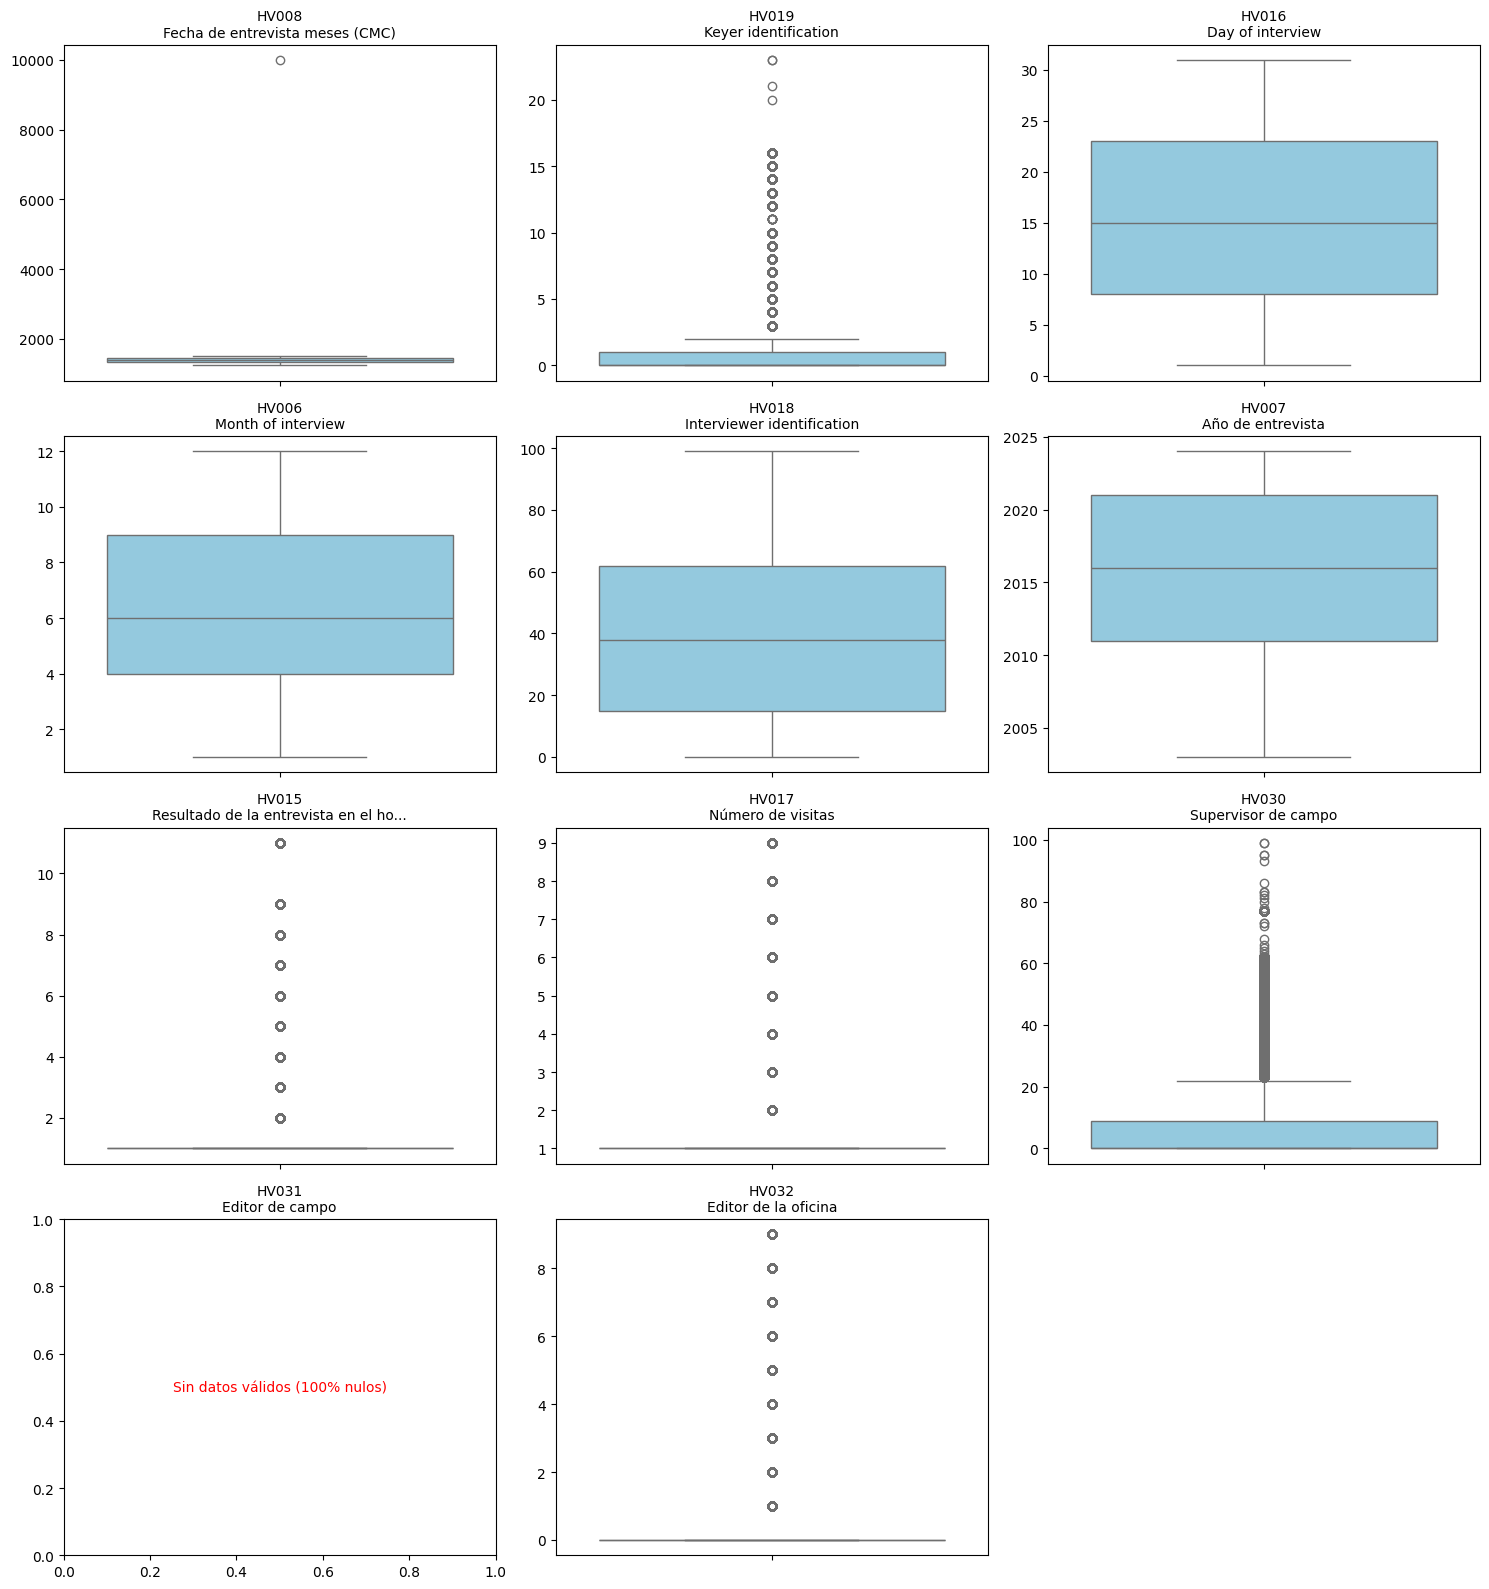

In [36]:
analizar_distribucion_y_atipicos('administrativa')

### Conclusiones: Variable Temporal (Fecha)

* **`HV008` (Fecha de entrevista - CMC)**: Registra la fecha de la encuesta en formato estadístico *Century Month Code* (conteo de meses transcurridos desde enero de 1900). Presenta una cobertura total en la base (608,995 registros).
* **Alerta de Atípico (`9999`)**: El valor máximo reportado es `9999`. En este tipo de bases de datos, esta cifra no es una fecha extrema, sino un código estándar usado para señalar un "dato faltante" o error en el registro.
    * **Acción para limpieza**: Es fundamental **reemplazar el valor `9999` por nulo (`NaN`)** antes de hacer cualquier procesamiento. Si no se remueve, arruinará cualquier conversión a fechas normales. Una vez limpio, el número puede transformarse a Año y Mes calendario.

* **`HV007` (Año de entrevista)**: Muestra una alta cobertura (571,509 registros válidos). Su rango es completamente lógico, abarcando desde el año `2003` hasta el `2024`. Esto confirma que estás trabajando con una base consolidada de poco más de 20 años de encuestas.
    * **Acción para limpieza**: No presenta valores atípicos (no hay `9999` como en los meses). Los años que falten (nulos) podrían ser imputados fácilmente cruzando la información o extrayéndola del código CMC (`HV008`). Se recomienda convertir a entero (`int16`).

### Conclusiones: Variable Operativa (Metadato Interno)

* **`HV019` (Identificación del digitador)**: Corresponde al código numérico (del 0 al 23) asignado a la persona que ingresó la encuesta al sistema. 
* **Cobertura incompleta**: Muestra una pérdida importante de datos, contando solo con 325,217 registros válidos frente a los casi 609 mil totales.
    * **Acción para limpieza**: Al ser estrictamente un registro de control de calidad del personal digitador, carece de utilidad para el análisis de los hogares o la salud. Por ello, y sumado a su gran cantidad de nulos, **se recomienda eliminar (dropear) esta columna** de la base de datos final.

* **`HV018` (Identificación del entrevistador)**: Sigue el mismo patrón que el ID del digitador anterior. Es un código (del 0 al 99) con mucha pérdida de datos (solo 346,247 registros).
* **`HV017` (Número de visitas)**: Indica cuántas visitas se hicieron al hogar (del 1 al 9). Tiene cobertura total (608,995), y el percentil 75% nos dice que la gran mayoría de encuestas se lograron en la primera visita (`1`).
* **`HV015` (Resultado de la entrevista)**: Registra si la encuesta fue exitosa, rechazada o quedó a medias (códigos del 1 al 11). También tiene cobertura total.
    * **Acción para limpieza**: 
        * Para **`HV018`** y **`HV017`**: **Eliminarlas (dropear)**. Son datos puramente logísticos de campo que no aportan a los indicadores del estudio.
        * Para **`HV015`**: Es clave **filtrar la base** para quedarse únicamente con los registros donde el resultado fue "Entrevista Completa" (típicamente el valor `1` en las ENDES). Una vez aplicado este filtro para limpiar las encuestas fallidas, la columna en sí también se puede eliminar.
* **`HV030` (Supervisor de campo)** y **`HV032` (Editor de la oficina)**: Ambas cuentan con una cobertura prácticamente total (~608,995 registros) y contienen los códigos de identificación del personal encargado de supervisar y revisar los datos (valores del 0 al 99 y del 0 al 9, respectivamente).
* **Alerta de Vacíos en `HV031` (Editor de campo)**: Destaca fuertemente por tener un recuento de `0.0`. Esto significa que es una **columna completamente vacía** (compuesta al 100% por valores nulos o `NaN`).
    * **Acción para limpieza**: 
        * Al igual que el identificador del digitador o entrevistador que vimos antes, estas tres variables son de uso exclusivo para la gestión interna de planillas de la ENDES y no tienen utilidad para estudios demográficos o de salud.
        * Se recomienda **eliminar (dropear) las tres columnas** de la base de análisis para optimizarla, empezando con `HV031` por ser una columna sin datos.

  DISTRIBUCIÓN Y ATÍPICOS: DEMOGRAFIA


,Etiqueta,count,mean,std,min,25%,50%,75%,max
HV009,Total de personas en el hogar,608995.0,3.762405,2.168134,0.0,2.0,4.0,5.0,24.0
HV010,Número de mujeres elegibles para entrevista individual,608995.0,0.902988,0.782153,0.0,0.0,1.0,1.0,8.0
HV011,Número de hombres elegibles por hogar,608995.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
HV012,Número de miembros de jure (residentes habituales),608995.0,3.689970,2.129263,0.0,2.0,4.0,5.0,24.0
HV013,Número de miembros de facto (personas que durmieron la noche anterior),608995.0,3.575054,2.152805,0.0,2.0,4.0,5.0,24.0
HV014,Número de niños menores de 5 años,608995.0,0.596634,0.727753,0.0,0.0,0.0,1.0,10.0
HV035,Número de niños elegibles para altura y peso,608995.0,0.506249,0.656944,0.0,0.0,0.0,1.0,7.0
HV041,Número de mujeres con medición de peso y talla,608995.0,0.949653,0.841329,0.0,0.0,1.0,1.0,9.0


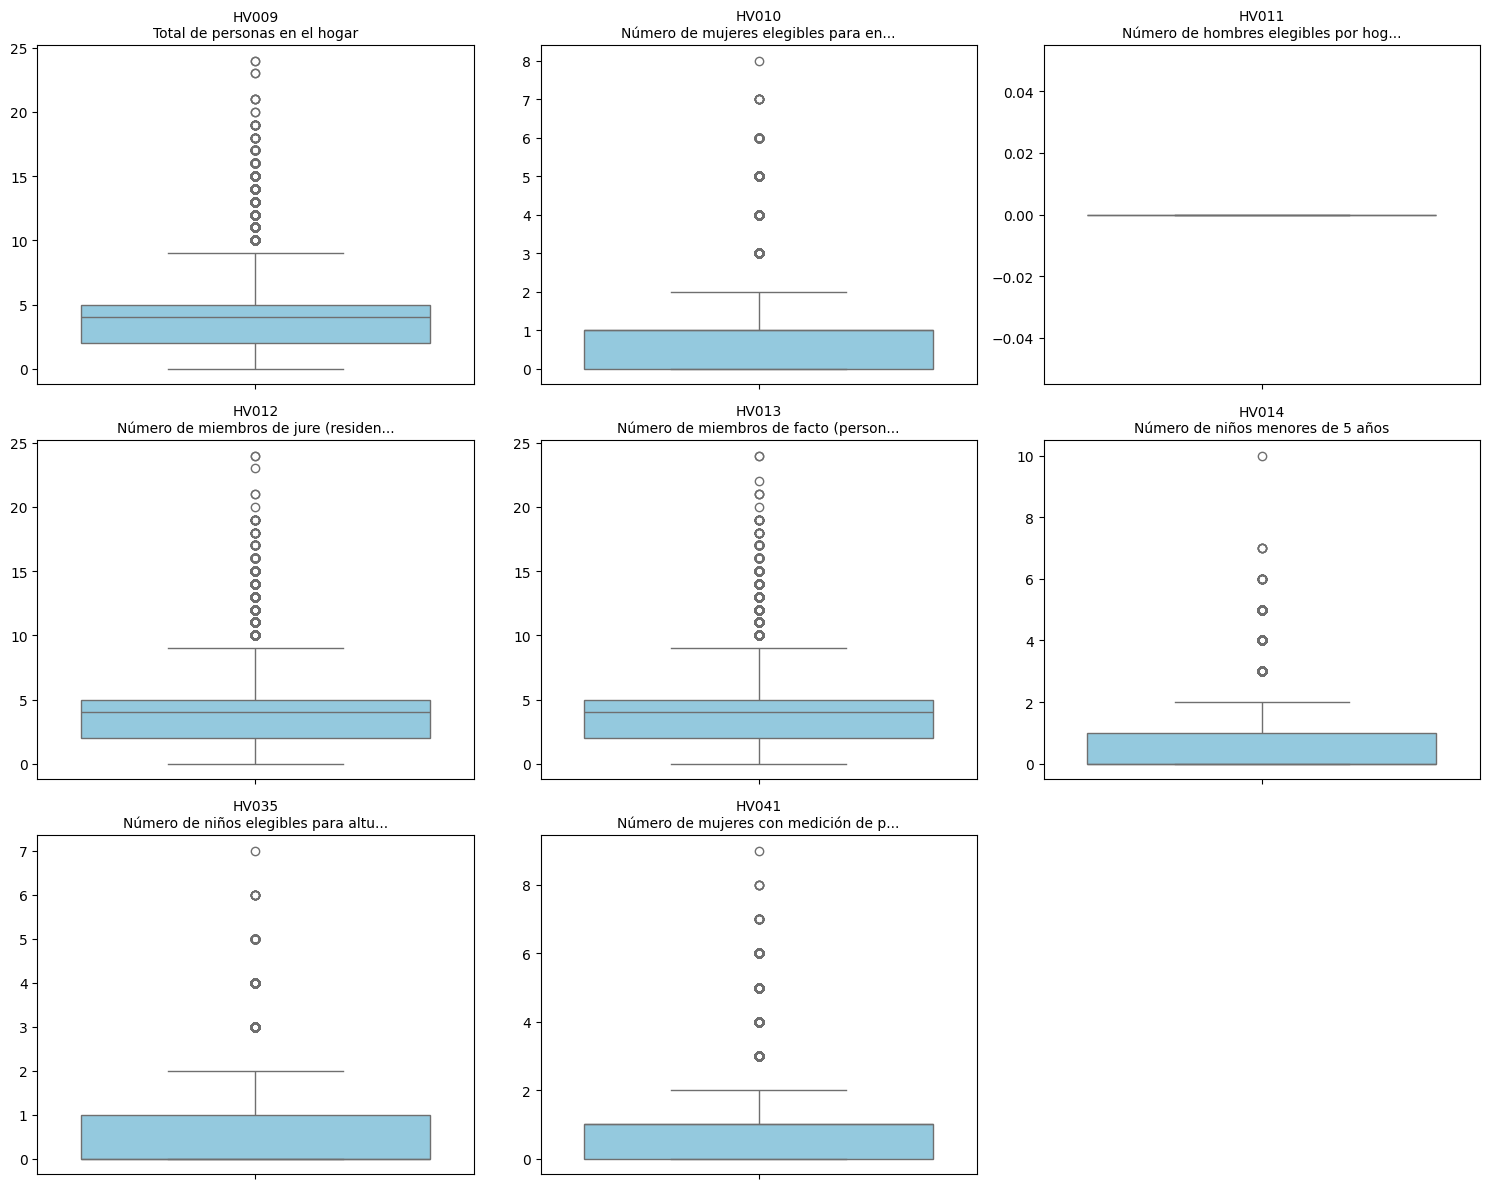

In [39]:
analizar_distribucion_y_atipicos('demografia')

#### Categoría: Demografía (Composición del Hogar)

**1. Valores Atípicos Lógicos**
Las variables de tamaño del hogar (`HV009`, `HV012`) presentan un máximo de 24 personas y la cantidad de mujeres elegibles (`HV010`) un máximo de 8. Aunque altos, son valores demográficamente posibles en viviendas rurales o multifamiliares en Perú. Lo vital aquí es que no hay presencia del código de error "99", lo que valida la calidad de la distribución.

**2. Hogares Vacíos**
La variable `HV009` presenta un valor mínimo de 0.0. Un hogar encuestado no puede tener cero habitantes de forma natural. Estos registros corresponden casi con seguridad a viviendas seleccionadas en el muestreo que resultaron estar desocupadas, destruidas o donde hubo rechazo total a la entrevista.

**3. Varianza Cero (Hombres Elegibles)**
La variable `HV011` (Número de hombres elegibles) es una constante absoluta: todos sus estadísticos (min, max, mean) son exactamente 0.0. Esto confirma la naturaleza del módulo recolectado, enfocado exclusivamente en salud materno-infantil.

**Acciones para la Limpieza:**
- **Filtro de Rechazos:** Cruzar los registros donde `HV009 == 0` con la variable de resultado de entrevista (`HV015`). Si la vivienda estaba desocupada o hubo rechazo, ese registro completo debe ser descartado (drop) del dataset.
- **Reducción de Dimensionalidad:** Eliminar permanentemente la columna `HV011` del pipeline. Al tener una varianza de cero (todos sus valores son 0), matemáticamente es inútil y no aportará ningún poder predictivo al modelo de Machine Learning.

**1. Consistencia Lógica de Menores**
La variable `HV014` (Niños menores de 5 años) presenta un máximo de 10.0. Aunque extremo, en la metodología de la encuesta una vivienda puede albergar múltiples familias nucleares, por lo que es demográficamente válido. Además, es lógicamente consistente que `HV035` (Niños elegibles para peso y talla) tenga un máximo menor (7.0), demostrando que no existen errores sistémicos donde los elegibles superen a la población total infantil.

**2. Identificación del Sesgo de Inclusión (Target)**
El percentil 50 de `HV014` es 0.0. Esto indica que por lo menos la mitad de los más de 600 mil hogares encuestados no tienen niños menores de 5 años. Dado que nuestro objetivo es pronosticar la desnutrición infantil, la mitad de los registros de esta tabla son irrelevantes para el modelo predictivo.

**3. Leve Inconsistencia en Mujeres**
La variable `HV041` (Mujeres con medición) muestra un máximo de 9.0, cifra que supera el máximo de 8.0 observado en `HV010` (Mujeres elegibles para entrevista). Esto representa una anomalía aislada donde físicamente se midió a más mujeres de las consideradas formalmente elegibles en la vivienda.

**Acciones para la Limpieza:**
- **Filtro de Criterio de Inclusión:** Antes de ejecutar el merge (unión) con las tablas clínicas, se debe aplicar una máscara de filtrado para conservar estrictamente los hogares donde `HV014 > 0` o `HV035 > 0`. Cargar hogares sin niños al modelo consumirá memoria y generará ruido estadístico.
- **Conservación de Extremos:** Mantener los valores máximos intactos. Un hogar con 10 niños es un dato atípico real (outlier biológico/social), no un error de digitación, por lo que el algoritmo de Machine Learning debe aprender de él.


In [33]:
# =====================================================================
# 3. Verificación de Cardinalidad (Frecuencias Reales vs. Diccionarios)
# =====================================================================
vars_categoricas = ['HV024', 'HV025', 'HV026', 'HV027'] # Región, Área de residencia, Lugar de residencia, Selección
vars_cat_existentes = [v for v in vars_categoricas if v in df_rech0.columns]

for col in vars_cat_existentes:
    # Usar el diccionario del último año (2024) como la verdad fundamental más actualizada
    mapa_dict = historial_valores.get(max(historial_valores.keys()), {}).get(col, {})
    if not mapa_dict:
        print(f"⚠️ [{col}] No tiene diccionario de valores mapeado.")
        continue
    
    # Normalizamos los tipos a string (quitando '.0' si son floats) para una comparación exacta
    valores_reales = set(df_rech0[col].dropna().astype(str).str.replace('.0', '', regex=False))
    valores_esperados = set(str(k).replace('.0', '') for k in mapa_dict.keys())
    
    intrusos = valores_reales - valores_esperados
    
    if intrusos:
        print(f"⚠️ [{col}] {diccionario.get(col, '')} -> {len(intrusos)} valores extraños NO mapeados en el diccionario: {intrusos}")
        # Imprimir cuántas veces aparece el error
        frec_intrusos = df_rech0[df_rech0[col].astype(str).str.replace('.0', '', regex=False).isin(intrusos)][col].value_counts()
        display(frec_intrusos)
    else:
        print(f"✅ [{col}] {diccionario.get(col, '')} -> 100% de los datos coinciden perfectamente con el diccionario.")


✅ [HV024] Región -> 100% de los datos coinciden perfectamente con el diccionario.
✅ [HV025] Área de residencia -> 100% de los datos coinciden perfectamente con el diccionario.
✅ [HV026] Lugar de residencia -> 100% de los datos coinciden perfectamente con el diccionario.
✅ [HV027] Selección para hombre/esposo -> 100% de los datos coinciden perfectamente con el diccionario.
